In [1]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
dia = "20251015"

dia_i = '15/10/2025'
dia_f = '15/10/2025'

Viaje desglosado

In [3]:
#Viaje desglosado

desglosado_z = pd.read_csv(f'Z:/01 base_datos/01 viajes_desglosados/{dia}_viajedesglosado.csv', skiprows=1,encoding='latin')
desglosado_t = pd.read_csv(f'Z:/01 base_datos/16 viajes_desglosados_troncal/{dia}_viajedesglosadotroncal.csv', skiprows=1,encoding='latin')

desglosado = pd.concat([desglosado_z,desglosado_t], ignore_index=True)

# Separar la columna 'Linea_Ruta' en dos columnas: 'Linea' y 'Ruta_C'
desglosado[['Linea', 'Ruta_C']] = desglosado['Línea'].str.split(' ', n=1, expand=True)

# Eliminar filas que contienen valores NaN en las columnas 'Linea' o 'Ruta_C'
desglosado = desglosado.dropna(subset=['Linea', 'Ruta_C'])

# Eliminar los corchetes de la columna 'Linea' y convertir a int
desglosado['Linea'] = desglosado['Linea'].str.replace('[\[\]]', '', regex=True).fillna(0).astype(int)

desglosado

<>:15: SyntaxWarning: invalid escape sequence '\['
<>:15: SyntaxWarning: invalid escape sequence '\['
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_8764\3039145039.py:15: SyntaxWarning: invalid escape sequence '\['
  desglosado['Linea'] = desglosado['Linea'].str.replace('[\[\]]', '', regex=True).fillna(0).astype(int)
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_8764\3039145039.py:15: SyntaxWarning: invalid escape sequence '\['
  desglosado['Linea'] = desglosado['Linea'].str.replace('[\[\]]', '', regex=True).fillna(0).astype(int)


FileNotFoundError: [Errno 2] No such file or directory: 'Z:/01 base_datos/16 viajes_desglosados_troncal/20251015_viajedesglosadotroncal.csv'

In [ ]:
# Función para corregir tiempos con "24:00:00"
def fix_time(date_str):
    if '24:' in date_str:
        return date_str.replace('24:', '00:')
    elif '25:' in date_str:
        return date_str.replace('25:', '01:')
    elif '26:' in date_str:
        return date_str.replace('26:', '02:')
    elif '27:' in date_str:
        return date_str.replace('27:', '03:')
    elif '28:' in date_str:
        return date_str.replace('28:', '04:')
    elif '29:' in date_str:
        return date_str.replace('29:', '05:')
    else:
        return date_str

# Función para convertir tiempo a segundos
def time_to_seconds(time_obj):
    return time_obj.hour * 3600 + time_obj.minute * 60 + time_obj.second

# Convertir la columna de tiempo a cadenas
desglosado['Hora Teórica'] = desglosado['Hora Teórica'].astype(str)

# Aplicar la función para corregir los tiempos
desglosado['Hora Teórica'] = desglosado['Hora Teórica'].apply(fix_time)

# Convertir la columna de tiempo a datetime, usando errors='coerce' para manejar errores
desglosado['Hora Teórica'] = pd.to_datetime(desglosado['Hora Teórica'], format='%H:%M:%S', errors='coerce')

# Eliminar la fecha predeterminada para trabajar solo con la parte de tiempo
desglosado['Hora Teórica'] = desglosado['Hora Teórica'].dt.time

# Manejar NaT después de la conversión
desglosado['Hora Teórica'] = desglosado['Hora Teórica'].apply(lambda x: x if pd.notnull(x) else pd.Timestamp('00:00:00').time())

# Convertir la columna 'Instante' a segundos
desglosado['Hora Teórica_segundos'] = desglosado['Hora Teórica'].apply(time_to_seconds).astype(int)

desglosado

,Fecha,Operador,Servicio Bus,Orden Viaje,Id. Viaje,Línea,Coche,Viaje Línea,Hora Teórica,Hora Referencia,...,Duración teórica,Duración referencia,Duración Real,Límite inferior teórico,Límite superior teórico,Límite inferior referencia,Límite superior referencia,Linea,Ruta_C,Hora Teórica_segundos
0,07/07/2025,[105] E,CEI2V0003,2.0,2.0,[1521] 5-4,2.0,1.0,04:18:00,4:18:00,...,0:34:00,0:34:00,0:20:35,0:05:15,0:15:45,0:05:15,0:15:45,1521,5-4,15480
1,07/07/2025,[105] E,CEI2V0003,3.0,3.0,[1521] 5-4,2.0,2.0,04:55:30,4:55:30,...,0:38:00,0:38:00,0:24:24,0:04:07,0:12:22,0:04:07,0:12:22,1521,5-4,17730
2,07/07/2025,[105] E,CEI2V0003,4.0,4.0,[1521] 5-4,2.0,3.0,05:36:45,5:36:45,...,0:38:00,0:38:00,0:27:55,0:04:07,0:12:22,0:04:07,0:12:22,1521,5-4,20205
3,07/07/2025,[105] E,CEI2V0003,5.0,5.0,[1521] 5-4,2.0,4.0,06:18:00,6:18:00,...,0:41:15,0:41:15,0:32:06,0:04:07,0:12:22,0:04:07,0:12:22,1521,5-4,22680
4,07/07/2025,[105] E,CEI2V0003,6.0,6.0,[1521] 5-4,2.0,5.0,06:59:15,6:59:15,...,0:44:00,0:44:00,0:37:56,0:04:07,0:12:22,0:04:07,0:12:22,1521,5-4,25155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,07/07/2025,[105] E,COA6B0012,20.0,20.0,[173] 1-9 V.,5.0,19.0,16:42:30,16:42:30,...,0:36:00,0:36:00,0:28:28,0:02:45,0:08:15,0:02:45,0:08:15,173,1-9 V.,60150
4005,07/07/2025,[105] E,COA6B0012,21.0,21.0,[173] 1-9 V.,5.0,20.0,17:21:00,17:21:00,...,0:36:00,0:36:00,0:34:26,0:02:45,0:08:15,0:02:45,0:08:15,173,1-9 V.,62460
4006,07/07/2025,[105] E,COA6B0012,22.0,22.0,[173] 1-9 V.,5.0,21.0,17:59:30,17:59:30,...,0:39:00,0:39:00,0:58:31,0:02:45,0:08:15,0:02:45,0:08:15,173,1-9 V.,64770
4007,07/07/2025,[105] E,COA6B0012,23.0,23.0,[173] 1-9 V.,5.0,22.0,18:42:30,18:42:30,...,0:40:00,0:40:00,0:48:42,0:03:07,0:09:22,0:03:07,0:09:22,173,1-9 V.,67350


In [ ]:
# Ordenar el DataFrame por 'Linea', 'Ruta' y 'Hora Teórica'
desglosado = desglosado.sort_values(by=['Linea', 'Ruta', 'Servicio Bus','Hora Teórica_segundos'], ascending=[True, True, True,True])

desglosado

,Fecha,Operador,Servicio Bus,Orden Viaje,Id. Viaje,Línea,Coche,Viaje Línea,Hora Teórica,Hora Referencia,...,Duración teórica,Duración referencia,Duración Real,Límite inferior teórico,Límite superior teórico,Límite inferior referencia,Límite superior referencia,Linea,Ruta_C,Hora Teórica_segundos
3206,07/07/2025,[105] E,CE4E70007,2.0,2.0,[59] 16-1 T,1.0,1.0,04:05:00,4:05:00,...,0:25:00,0:25:00,0:22:22,NaN,NaN,NaN,NaN,59,16-1 T,14700
3207,07/07/2025,[105] E,CE4E70007,3.0,3.0,[59] 16-1 T,1.0,2.0,04:31:15,4:31:15,...,0:32:00,0:32:00,0:22:17,0:04:22,0:13:07,0:04:22,0:13:07,59,16-1 T,16275
3208,07/07/2025,[105] E,CE4E70007,4.0,4.0,[59] 16-1 T,1.0,3.0,05:06:15,5:06:15,...,0:35:00,0:35:00,0:26:59,0:04:22,0:13:07,0:04:22,0:13:07,59,16-1 T,18375
3209,07/07/2025,[105] E,CE4E70007,5.0,5.0,[59] 16-1 T,1.0,4.0,05:41:15,5:41:15,...,0:38:00,0:38:00,0:30:36,0:03:30,0:10:30,0:03:30,0:10:30,59,16-1 T,20475
3210,07/07/2025,[105] E,CE4E70007,6.0,6.0,[59] 16-1 T,1.0,5.0,06:21:15,6:21:15,...,0:42:00,0:42:00,0:35:31,0:04:00,0:12:00,0:04:00,0:12:00,59,16-1 T,22875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,07/07/2025,[105] E,CEIKD0041,6.0,6.0,[1686] BD237,41.0,9.0,21:46:15,21:46:15,...,1:53:00,1:48:45,1:36:00,0:08:30,0:25:30,0:08:30,0:25:30,1686,BD237,78375
1345,07/07/2025,[105] E,CEIKDG018,1.0,1.0,[1686] BD237,43.0,1.0,19:33:15,19:33:15,...,2:30:30,1:56:23,1:38:14,0:02:30,0:07:30,0:02:30,0:07:30,1686,BD237,70395
1346,07/07/2025,[105] E,CEIKDG018,2.0,2.0,[1686] BD237,43.0,2.0,22:04:45,22:04:45,...,1:47:00,1:47:00,1:38:43,0:09:15,0:27:45,0:09:15,0:27:45,1686,BD237,79485
1347,07/07/2025,[105] E,CEIKDG025,1.0,1.0,[1686] BD237,42.0,1.0,12:34:45,12:34:45,...,3:32:00,3:32:00,NaN,0:03:00,0:09:00,0:03:00,0:09:00,1686,BD237,45285


In [ ]:
# Encontrar el mínimo de 'Hora Teórica_segundos' por cada 'Servicio Bus'
desglosado['Primer Viaje'] = (desglosado.groupby('Servicio Bus')['Hora Teórica_segundos']
                         .transform('min') == desglosado['Hora Teórica_segundos']).astype(int)

desglosado


,Fecha,Operador,Servicio Bus,Orden Viaje,Id. Viaje,Línea,Coche,Viaje Línea,Hora Teórica,Hora Referencia,...,Duración referencia,Duración Real,Límite inferior teórico,Límite superior teórico,Límite inferior referencia,Límite superior referencia,Linea,Ruta_C,Hora Teórica_segundos,Primer Viaje
3206,07/07/2025,[105] E,CE4E70007,2.0,2.0,[59] 16-1 T,1.0,1.0,04:05:00,4:05:00,...,0:25:00,0:22:22,NaN,NaN,NaN,NaN,59,16-1 T,14700,1
3207,07/07/2025,[105] E,CE4E70007,3.0,3.0,[59] 16-1 T,1.0,2.0,04:31:15,4:31:15,...,0:32:00,0:22:17,0:04:22,0:13:07,0:04:22,0:13:07,59,16-1 T,16275,0
3208,07/07/2025,[105] E,CE4E70007,4.0,4.0,[59] 16-1 T,1.0,3.0,05:06:15,5:06:15,...,0:35:00,0:26:59,0:04:22,0:13:07,0:04:22,0:13:07,59,16-1 T,18375,0
3209,07/07/2025,[105] E,CE4E70007,5.0,5.0,[59] 16-1 T,1.0,4.0,05:41:15,5:41:15,...,0:38:00,0:30:36,0:03:30,0:10:30,0:03:30,0:10:30,59,16-1 T,20475,0
3210,07/07/2025,[105] E,CE4E70007,6.0,6.0,[59] 16-1 T,1.0,5.0,06:21:15,6:21:15,...,0:42:00,0:35:31,0:04:00,0:12:00,0:04:00,0:12:00,59,16-1 T,22875,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,07/07/2025,[105] E,CEIKD0041,6.0,6.0,[1686] BD237,41.0,9.0,21:46:15,21:46:15,...,1:48:45,1:36:00,0:08:30,0:25:30,0:08:30,0:25:30,1686,BD237,78375,0
1345,07/07/2025,[105] E,CEIKDG018,1.0,1.0,[1686] BD237,43.0,1.0,19:33:15,19:33:15,...,1:56:23,1:38:14,0:02:30,0:07:30,0:02:30,0:07:30,1686,BD237,70395,1
1346,07/07/2025,[105] E,CEIKDG018,2.0,2.0,[1686] BD237,43.0,2.0,22:04:45,22:04:45,...,1:47:00,1:38:43,0:09:15,0:27:45,0:09:15,0:27:45,1686,BD237,79485,0
1347,07/07/2025,[105] E,CEIKDG025,1.0,1.0,[1686] BD237,42.0,1.0,12:34:45,12:34:45,...,3:32:00,NaN,0:03:00,0:09:00,0:03:00,0:09:00,1686,BD237,45285,1


Eliminación cuando es primer viaje

In [ ]:
# Crear la nueva columna 'Resultado' basada en las condiciones proporcionadas
desglosado['Eliminacion_primer_viaje'] = np.where(
    (desglosado['Primer Viaje'] == 1) &
    (desglosado['Eliminado'] == 'Eliminado') &
    (desglosado['Descripción Motivo Adición, eliminación o sustitución de viaje'] == 'Congestión vehicular'),
    1,
    0
)

# Mostrar el DataFrame resultante
desglosado

,Fecha,Operador,Servicio Bus,Orden Viaje,Id. Viaje,Línea,Coche,Viaje Línea,Hora Teórica,Hora Referencia,...,Duración Real,Límite inferior teórico,Límite superior teórico,Límite inferior referencia,Límite superior referencia,Linea,Ruta_C,Hora Teórica_segundos,Primer Viaje,Eliminacion_primer_viaje
3206,07/07/2025,[105] E,CE4E70007,2.0,2.0,[59] 16-1 T,1.0,1.0,04:05:00,4:05:00,...,0:22:22,NaN,NaN,NaN,NaN,59,16-1 T,14700,1,0
3207,07/07/2025,[105] E,CE4E70007,3.0,3.0,[59] 16-1 T,1.0,2.0,04:31:15,4:31:15,...,0:22:17,0:04:22,0:13:07,0:04:22,0:13:07,59,16-1 T,16275,0,0
3208,07/07/2025,[105] E,CE4E70007,4.0,4.0,[59] 16-1 T,1.0,3.0,05:06:15,5:06:15,...,0:26:59,0:04:22,0:13:07,0:04:22,0:13:07,59,16-1 T,18375,0,0
3209,07/07/2025,[105] E,CE4E70007,5.0,5.0,[59] 16-1 T,1.0,4.0,05:41:15,5:41:15,...,0:30:36,0:03:30,0:10:30,0:03:30,0:10:30,59,16-1 T,20475,0,0
3210,07/07/2025,[105] E,CE4E70007,6.0,6.0,[59] 16-1 T,1.0,5.0,06:21:15,6:21:15,...,0:35:31,0:04:00,0:12:00,0:04:00,0:12:00,59,16-1 T,22875,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,07/07/2025,[105] E,CEIKD0041,6.0,6.0,[1686] BD237,41.0,9.0,21:46:15,21:46:15,...,1:36:00,0:08:30,0:25:30,0:08:30,0:25:30,1686,BD237,78375,0,0
1345,07/07/2025,[105] E,CEIKDG018,1.0,1.0,[1686] BD237,43.0,1.0,19:33:15,19:33:15,...,1:38:14,0:02:30,0:07:30,0:02:30,0:07:30,1686,BD237,70395,1,0
1346,07/07/2025,[105] E,CEIKDG018,2.0,2.0,[1686] BD237,43.0,2.0,22:04:45,22:04:45,...,1:38:43,0:09:15,0:27:45,0:09:15,0:27:45,1686,BD237,79485,0,0
1347,07/07/2025,[105] E,CEIKDG025,1.0,1.0,[1686] BD237,42.0,1.0,12:34:45,12:34:45,...,NaN,0:03:00,0:09:00,0:03:00,0:09:00,1686,BD237,45285,1,0


In [ ]:
# Función para corregir tiempos con "24:00:00"
def fix_time(date_str):
    if '24:' in date_str:
        return date_str.replace('24:', '00:')
    elif '25:' in date_str:
        return date_str.replace('25:', '01:')
    elif '26:' in date_str:
        return date_str.replace('26:', '02:')
    elif '27:' in date_str:
        return date_str.replace('27:', '03:')
    elif '28:' in date_str:
        return date_str.replace('28:', '04:')
    elif '29:' in date_str:
        return date_str.replace('29:', '05:')
    else:
        return date_str

# Función para convertir tiempo a segundos
def time_to_seconds(time_obj):
    return time_obj.hour * 3600 + time_obj.minute * 60 + time_obj.second

# Convertir la columna de tiempo a cadenas
desglosado['Duración teórica'] = desglosado['Duración teórica'].astype(str)
desglosado['Duración referencia'] = desglosado['Duración referencia'].astype(str)
desglosado['Duración Real'] = desglosado['Duración Real'].astype(str)

# Aplicar la función para corregir los tiempos
desglosado['Duración teórica'] = desglosado['Duración teórica'].apply(fix_time)
desglosado['Duración referencia'] = desglosado['Duración referencia'].apply(fix_time)
desglosado['Duración Real'] = desglosado['Duración Real'].apply(fix_time)

# Convertir la columna de tiempo a datetime, usando errors='coerce' para manejar errores
desglosado['Duración teórica'] = pd.to_datetime(desglosado['Duración teórica'], format='%H:%M:%S', errors='coerce')
desglosado['Duración referencia'] = pd.to_datetime(desglosado['Duración referencia'], format='%H:%M:%S', errors='coerce')
desglosado['Duración Real'] = pd.to_datetime(desglosado['Duración Real'], format='%H:%M:%S', errors='coerce')

# Eliminar la fecha predeterminada para trabajar solo con la parte de tiempo
desglosado['Duración teórica'] = desglosado['Duración teórica'].dt.time
desglosado['Duración referencia'] = desglosado['Duración referencia'].dt.time
desglosado['Duración Real'] = desglosado['Duración Real'].dt.time

# Manejar NaT después de la conversión
desglosado['Duración teórica'] = desglosado['Duración teórica'].apply(lambda x: x if pd.notnull(x) else pd.Timestamp('00:00:00').time())
desglosado['Duración referencia'] = desglosado['Duración referencia'].apply(lambda x: x if pd.notnull(x) else pd.Timestamp('00:00:00').time())
desglosado['Duración Real'] = desglosado['Duración Real'].apply(lambda x: x if pd.notnull(x) else pd.Timestamp('00:00:00').time())

# Convertir la columna 'Instante' a segundos
desglosado['Duración teórica_segundos'] = desglosado['Duración teórica'].apply(time_to_seconds).astype(int)
desglosado['Duración referencia_segundos'] = desglosado['Duración referencia'].apply(time_to_seconds).astype(int)
desglosado['Duración Real_segundos'] = desglosado['Duración Real'].apply(time_to_seconds).astype(int)

desglosado

,Fecha,Operador,Servicio Bus,Orden Viaje,Id. Viaje,Línea,Coche,Viaje Línea,Hora Teórica,Hora Referencia,...,Límite inferior referencia,Límite superior referencia,Linea,Ruta_C,Hora Teórica_segundos,Primer Viaje,Eliminacion_primer_viaje,Duración teórica_segundos,Duración referencia_segundos,Duración Real_segundos
3206,07/07/2025,[105] E,CE4E70007,2.0,2.0,[59] 16-1 T,1.0,1.0,04:05:00,4:05:00,...,NaN,NaN,59,16-1 T,14700,1,0,60,60,1342
3207,07/07/2025,[105] E,CE4E70007,3.0,3.0,[59] 16-1 T,1.0,2.0,04:31:15,4:31:15,...,0:04:22,0:13:07,59,16-1 T,16275,0,0,1920,1920,1337
3208,07/07/2025,[105] E,CE4E70007,4.0,4.0,[59] 16-1 T,1.0,3.0,05:06:15,5:06:15,...,0:04:22,0:13:07,59,16-1 T,18375,0,0,2100,2100,179
3209,07/07/2025,[105] E,CE4E70007,5.0,5.0,[59] 16-1 T,1.0,4.0,05:41:15,5:41:15,...,0:03:30,0:10:30,59,16-1 T,20475,0,0,2280,2280,1836
3210,07/07/2025,[105] E,CE4E70007,6.0,6.0,[59] 16-1 T,1.0,5.0,06:21:15,6:21:15,...,0:04:00,0:12:00,59,16-1 T,22875,0,0,2520,2520,2131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,07/07/2025,[105] E,CEIKD0041,6.0,6.0,[1686] BD237,41.0,9.0,21:46:15,21:46:15,...,0:08:30,0:25:30,1686,BD237,78375,0,0,6780,6525,5760
1345,07/07/2025,[105] E,CEIKDG018,1.0,1.0,[1686] BD237,43.0,1.0,19:33:15,19:33:15,...,0:02:30,0:07:30,1686,BD237,70395,1,0,9030,6983,5894
1346,07/07/2025,[105] E,CEIKDG018,2.0,2.0,[1686] BD237,43.0,2.0,22:04:45,22:04:45,...,0:09:15,0:27:45,1686,BD237,79485,0,0,6420,6420,5923
1347,07/07/2025,[105] E,CEIKDG025,1.0,1.0,[1686] BD237,42.0,1.0,12:34:45,12:34:45,...,0:03:00,0:09:00,1686,BD237,45285,1,0,12720,12720,0


In [ ]:
# Crear una nueva columna llamada 'Diferencia Duración' con la diferencia de las dos columnas
desglosado['Diferencia Duración'] = desglosado['Duración referencia_segundos'] - desglosado['Duración teórica_segundos']

# Mostrar el DataFrame con la nueva columna
desglosado

,Fecha,Operador,Servicio Bus,Orden Viaje,Id. Viaje,Línea,Coche,Viaje Línea,Hora Teórica,Hora Referencia,...,Límite superior referencia,Linea,Ruta_C,Hora Teórica_segundos,Primer Viaje,Eliminacion_primer_viaje,Duración teórica_segundos,Duración referencia_segundos,Duración Real_segundos,Diferencia Duración
3206,07/07/2025,[105] E,CE4E70007,2.0,2.0,[59] 16-1 T,1.0,1.0,04:05:00,4:05:00,...,NaN,59,16-1 T,14700,1,0,60,60,1342,0
3207,07/07/2025,[105] E,CE4E70007,3.0,3.0,[59] 16-1 T,1.0,2.0,04:31:15,4:31:15,...,0:13:07,59,16-1 T,16275,0,0,1920,1920,1337,0
3208,07/07/2025,[105] E,CE4E70007,4.0,4.0,[59] 16-1 T,1.0,3.0,05:06:15,5:06:15,...,0:13:07,59,16-1 T,18375,0,0,2100,2100,179,0
3209,07/07/2025,[105] E,CE4E70007,5.0,5.0,[59] 16-1 T,1.0,4.0,05:41:15,5:41:15,...,0:10:30,59,16-1 T,20475,0,0,2280,2280,1836,0
3210,07/07/2025,[105] E,CE4E70007,6.0,6.0,[59] 16-1 T,1.0,5.0,06:21:15,6:21:15,...,0:12:00,59,16-1 T,22875,0,0,2520,2520,2131,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,07/07/2025,[105] E,CEIKD0041,6.0,6.0,[1686] BD237,41.0,9.0,21:46:15,21:46:15,...,0:25:30,1686,BD237,78375,0,0,6780,6525,5760,-255
1345,07/07/2025,[105] E,CEIKDG018,1.0,1.0,[1686] BD237,43.0,1.0,19:33:15,19:33:15,...,0:07:30,1686,BD237,70395,1,0,9030,6983,5894,-2047
1346,07/07/2025,[105] E,CEIKDG018,2.0,2.0,[1686] BD237,43.0,2.0,22:04:45,22:04:45,...,0:27:45,1686,BD237,79485,0,0,6420,6420,5923,0
1347,07/07/2025,[105] E,CEIKDG025,1.0,1.0,[1686] BD237,42.0,1.0,12:34:45,12:34:45,...,0:09:00,1686,BD237,45285,1,0,12720,12720,0,0


In [ ]:
# Crear una nueva columna basada en la condición de que la columna de diferencia real es mayor a la programada
desglosado['Diferencia_realizado'] = (desglosado['Duración Real_segundos'] <= desglosado['Duración teórica_segundos']).astype(int)

# Mostrar el DataFrame con la nueva columna
desglosado

,Fecha,Operador,Servicio Bus,Orden Viaje,Id. Viaje,Línea,Coche,Viaje Línea,Hora Teórica,Hora Referencia,...,Linea,Ruta_C,Hora Teórica_segundos,Primer Viaje,Eliminacion_primer_viaje,Duración teórica_segundos,Duración referencia_segundos,Duración Real_segundos,Diferencia Duración,Diferencia_realizado
3206,07/07/2025,[105] E,CE4E70007,2.0,2.0,[59] 16-1 T,1.0,1.0,04:05:00,4:05:00,...,59,16-1 T,14700,1,0,60,60,1342,0,0
3207,07/07/2025,[105] E,CE4E70007,3.0,3.0,[59] 16-1 T,1.0,2.0,04:31:15,4:31:15,...,59,16-1 T,16275,0,0,1920,1920,1337,0,1
3208,07/07/2025,[105] E,CE4E70007,4.0,4.0,[59] 16-1 T,1.0,3.0,05:06:15,5:06:15,...,59,16-1 T,18375,0,0,2100,2100,179,0,1
3209,07/07/2025,[105] E,CE4E70007,5.0,5.0,[59] 16-1 T,1.0,4.0,05:41:15,5:41:15,...,59,16-1 T,20475,0,0,2280,2280,1836,0,1
3210,07/07/2025,[105] E,CE4E70007,6.0,6.0,[59] 16-1 T,1.0,5.0,06:21:15,6:21:15,...,59,16-1 T,22875,0,0,2520,2520,2131,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,07/07/2025,[105] E,CEIKD0041,6.0,6.0,[1686] BD237,41.0,9.0,21:46:15,21:46:15,...,1686,BD237,78375,0,0,6780,6525,5760,-255,1
1345,07/07/2025,[105] E,CEIKDG018,1.0,1.0,[1686] BD237,43.0,1.0,19:33:15,19:33:15,...,1686,BD237,70395,1,0,9030,6983,5894,-2047,1
1346,07/07/2025,[105] E,CEIKDG018,2.0,2.0,[1686] BD237,43.0,2.0,22:04:45,22:04:45,...,1686,BD237,79485,0,0,6420,6420,5923,0,1
1347,07/07/2025,[105] E,CEIKDG025,1.0,1.0,[1686] BD237,42.0,1.0,12:34:45,12:34:45,...,1686,BD237,45285,1,0,12720,12720,0,0,1


Duración real menor a la programada

In [ ]:
# # Restablecer el índice del DataFrame
# desglosado.reset_index(drop=True, inplace=True)

# # Crear una nueva columna para almacenar el resultado
# desglosado['Resultado'] = 0

# # Iterar por el DataFrame para aplicar la lógica
# for i in range(len(desglosado) - 1):
#     # Verificar la condición para la fila actual
#     if desglosado.loc[i, 'Diferencia_realizado'] == 1:
#         # Verificar la condición para la siguiente fila dentro de la misma Linea y Ruta
#         if (
#             desglosado.loc[i + 1, 'Servicio Bus'] == desglosado.loc[i, 'Servicio Bus'] and
#             desglosado.loc[i + 1, 'Linea'] == desglosado.loc[i, 'Linea'] and
#             desglosado.loc[i + 1, 'Ruta'] == desglosado.loc[i, 'Ruta'] and
#             desglosado.loc[i + 1, 'Eliminado'] == 'Eliminado' and
#             desglosado.loc[i + 1, 'Descripción Motivo Adición, eliminación o sustitución de viaje'] == 'Congestión vehicular'
#         ):
#             # Marcar como 1 si se cumplen todas las condiciones
#             desglosado.loc[i, 'Resultado'] = 1

# # Mostrar el DataFrame con la nueva columna
# desglosado

In [ ]:
# Restablecer el índice del DataFrame
desglosado.reset_index(drop=True, inplace=True)

# Crear una nueva columna para almacenar el resultado
desglosado['eliminacion_duracion_real_menor'] = 0

# Iterar por el DataFrame para aplicar la lógica
for i in range(1, len(desglosado) - 1):  # Comenzamos desde 1 para no ir al primer elemento (sin fila anterior)
    # Verificar la condición para la fila actual y la anterior
    if desglosado.loc[i, 'Diferencia_realizado'] == 1 and desglosado.loc[i - 1, 'Diferencia_realizado'] == 1:
        # Verificar las condiciones para la siguiente fila dentro de la misma Linea y Ruta
        if (
            desglosado.loc[i + 1, 'Servicio Bus'] == desglosado.loc[i, 'Servicio Bus'] and
            desglosado.loc[i + 1, 'Linea'] == desglosado.loc[i, 'Linea'] and
            desglosado.loc[i + 1, 'Ruta'] == desglosado.loc[i, 'Ruta'] and
            desglosado.loc[i + 1, 'Eliminado'] == 'Eliminado' and
            desglosado.loc[i + 1, 'Descripción Motivo Adición, eliminación o sustitución de viaje'] == 'Congestión vehicular'
        ):
            # Marcar como 1 si se cumplen todas las condiciones
            desglosado.loc[i, 'eliminacion_duracion_real_menor'] = 1

# Mostrar el DataFrame con la nueva columna
desglosado

,Fecha,Operador,Servicio Bus,Orden Viaje,Id. Viaje,Línea,Coche,Viaje Línea,Hora Teórica,Hora Referencia,...,Ruta_C,Hora Teórica_segundos,Primer Viaje,Eliminacion_primer_viaje,Duración teórica_segundos,Duración referencia_segundos,Duración Real_segundos,Diferencia Duración,Diferencia_realizado,eliminacion_duracion_real_menor
0,07/07/2025,[105] E,CE4E70007,2.0,2.0,[59] 16-1 T,1.0,1.0,04:05:00,4:05:00,...,16-1 T,14700,1,0,60,60,1342,0,0,0
1,07/07/2025,[105] E,CE4E70007,3.0,3.0,[59] 16-1 T,1.0,2.0,04:31:15,4:31:15,...,16-1 T,16275,0,0,1920,1920,1337,0,1,0
2,07/07/2025,[105] E,CE4E70007,4.0,4.0,[59] 16-1 T,1.0,3.0,05:06:15,5:06:15,...,16-1 T,18375,0,0,2100,2100,179,0,1,0
3,07/07/2025,[105] E,CE4E70007,5.0,5.0,[59] 16-1 T,1.0,4.0,05:41:15,5:41:15,...,16-1 T,20475,0,0,2280,2280,1836,0,1,0
4,07/07/2025,[105] E,CE4E70007,6.0,6.0,[59] 16-1 T,1.0,5.0,06:21:15,6:21:15,...,16-1 T,22875,0,0,2520,2520,2131,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4003,07/07/2025,[105] E,CEIKD0041,6.0,6.0,[1686] BD237,41.0,9.0,21:46:15,21:46:15,...,BD237,78375,0,0,6780,6525,5760,-255,1,0
4004,07/07/2025,[105] E,CEIKDG018,1.0,1.0,[1686] BD237,43.0,1.0,19:33:15,19:33:15,...,BD237,70395,1,0,9030,6983,5894,-2047,1,0
4005,07/07/2025,[105] E,CEIKDG018,2.0,2.0,[1686] BD237,43.0,2.0,22:04:45,22:04:45,...,BD237,79485,0,0,6420,6420,5923,0,1,0
4006,07/07/2025,[105] E,CEIKDG025,1.0,1.0,[1686] BD237,42.0,1.0,12:34:45,12:34:45,...,BD237,45285,1,0,12720,12720,0,0,1,0


Viaje eliminado por congestión precedido por una causal atribuible al concesionario

In [ ]:
# Restablecer el índice del DataFrame
desglosado.reset_index(drop=True, inplace=True)

# Crear una nueva columna para almacenar el resultado
desglosado['Eliminaciones consecutivas'] = 0

# Crear una nueva columna para almacenar si hay eliminaciones consecutivas
desglosado['eliminacion_servicio_anterior_motivo'] = 0

# Verificar si existen eliminaciones consecutivas
for i in range(1, len(desglosado) - 1):  # Aseguramos que no se salga del rango con len - 1
    # Verificar si hay dos eliminaciones consecutivas
    if desglosado.loc[i, 'Eliminado'] == 'Eliminado' and desglosado.loc[i - 1, 'Eliminado'] == 'Eliminado':
        # Marcar la columna 'Eliminaciones consecutivas' con 1 si hay eliminaciones consecutivas
        desglosado.loc[i, 'Eliminaciones consecutivas'] = 1
        desglosado.loc[i - 1, 'Eliminaciones consecutivas'] = 1
    else:
        # Si no hay eliminaciones consecutivas, continuar con la lógica de Congestión vehicular
        if desglosado.loc[i, 'Eliminado'] == 'Eliminado' or desglosado.loc[i, 'Eliminado'] == 'Parcial':
            if (
                desglosado.loc[i - 1, 'Eliminado'] != 'Congestión vehicular' and
                desglosado.loc[i - 1, 'Servicio Bus'] == desglosado.loc[i, 'Servicio Bus'] and
                desglosado.loc[i - 1, 'Linea'] == desglosado.loc[i, 'Linea'] and
                desglosado.loc[i - 1, 'Ruta'] == desglosado.loc[i, 'Ruta']
            ):
                # Condición para la fila siguiente (que debe tener "Congestión vehicular")
                if (
                    desglosado.loc[i + 1, 'Eliminado'] == 'Congestión vehicular' and
                    desglosado.loc[i + 1, 'Servicio Bus'] == desglosado.loc[i, 'Servicio Bus'] and
                    desglosado.loc[i + 1, 'Linea'] == desglosado.loc[i, 'Linea'] and
                    desglosado.loc[i + 1, 'Ruta'] == desglosado.loc[i, 'Ruta']
                ):
                    # Marcar como 1 si se cumplen todas las condiciones
                    desglosado.loc[i, 'eliminacion_servicio_anterior_motivo'] = 1

# Mostrar el DataFrame con las nuevas columnas
desglosado

,Fecha,Operador,Servicio Bus,Orden Viaje,Id. Viaje,Línea,Coche,Viaje Línea,Hora Teórica,Hora Referencia,...,Primer Viaje,Eliminacion_primer_viaje,Duración teórica_segundos,Duración referencia_segundos,Duración Real_segundos,Diferencia Duración,Diferencia_realizado,eliminacion_duracion_real_menor,Eliminaciones consecutivas,eliminacion_servicio_anterior_motivo
0,07/07/2025,[105] E,CE4E70007,2.0,2.0,[59] 16-1 T,1.0,1.0,04:05:00,4:05:00,...,1,0,60,60,1342,0,0,0,0,0
1,07/07/2025,[105] E,CE4E70007,3.0,3.0,[59] 16-1 T,1.0,2.0,04:31:15,4:31:15,...,0,0,1920,1920,1337,0,1,0,0,0
2,07/07/2025,[105] E,CE4E70007,4.0,4.0,[59] 16-1 T,1.0,3.0,05:06:15,5:06:15,...,0,0,2100,2100,179,0,1,0,0,0
3,07/07/2025,[105] E,CE4E70007,5.0,5.0,[59] 16-1 T,1.0,4.0,05:41:15,5:41:15,...,0,0,2280,2280,1836,0,1,0,0,0
4,07/07/2025,[105] E,CE4E70007,6.0,6.0,[59] 16-1 T,1.0,5.0,06:21:15,6:21:15,...,0,0,2520,2520,2131,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4003,07/07/2025,[105] E,CEIKD0041,6.0,6.0,[1686] BD237,41.0,9.0,21:46:15,21:46:15,...,0,0,6780,6525,5760,-255,1,0,0,0
4004,07/07/2025,[105] E,CEIKDG018,1.0,1.0,[1686] BD237,43.0,1.0,19:33:15,19:33:15,...,1,0,9030,6983,5894,-2047,1,0,0,0
4005,07/07/2025,[105] E,CEIKDG018,2.0,2.0,[1686] BD237,43.0,2.0,22:04:45,22:04:45,...,0,0,6420,6420,5923,0,1,0,0,0
4006,07/07/2025,[105] E,CEIKDG025,1.0,1.0,[1686] BD237,42.0,1.0,12:34:45,12:34:45,...,1,0,12720,12720,0,0,1,0,0,0


In [ ]:
# Ver los valores de una columna específica
valores_unicos = desglosado['eliminacion_servicio_anterior_motivo'].unique()

print(valores_unicos)

[0]


IPH

In [ ]:
#IPH GM

iph_zonal = pd.read_csv(f'Z:/01 base_datos/12 iph/{dia}_iph_zonal.csv')
iph_troncal = pd.read_csv(f'Z:/01 base_datos/34 iph alim/{dia}_iph_alim.csv')

#Concatenado de dataframes IPH Completa

iph = pd.concat([iph_zonal,iph_troncal], ignore_index=True)

# Rellenar valores faltantes en Sublinea y Ruta basados en TipoDia, ServBus, y Coche
iph[['Sublinea', 'Ruta']] = iph.groupby(['TipoDia', 'ServBus', 'Coche'])[['Sublinea', 'Ruta']].transform(lambda x: x.ffill().bfill())

# Rellenar valores faltantes en ServicioCondEnt y ServicioCondSal basados en TipoDia, ServBus, Linea, Ruta, Coche y Viaje
iph[['ServicioCondEnt', 'ServicioCondSal']] = iph.groupby(['TipoDia', 'ServBus', 'Linea', 'Ruta', 'Coche'])[['ServicioCondEnt', 'ServicioCondSal']].transform(lambda x: x.ffill().bfill())

iph

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16588\999564515.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iph[['ServicioCondEnt', 'ServicioCondSal']] = iph.groupby(['TipoDia', 'ServBus', 'Linea', 'Ruta', 'Coche'])[['ServicioCondEnt', 'ServicioCondSal']].transform(lambda x: x.ffill().bfill())


,JornadaTipo,TipoDia,Operador,Instante,ServBus,Evento,Linea,Coche,Sublinea,Ruta,Punto,TipoNodo,Viaje,ServicioCondEnt,TurnoEnt,OperadorEnt,ServicioCondSal,TipoVehiculo
0,GC250624T2,CN00111830,105,3:20:00,CNLYU0001,18,1300,1,4097.0,5658.0,142,5.0,1,CE130330,1.0,105.0,CE130330,8
1,GC250624T2,CN00111830,105,4:00:00,CNLYU0001,4,1300,1,4097.0,5658.0,52372,1.0,1,CE130330,NaN,NaN,CE130330,8
2,GC250624T2,CN00111830,105,4:00:00,CNLYU0001,11,1300,1,4097.0,5658.0,52372,1.0,2,CE130330,NaN,NaN,CE130330,8
3,GC250624T2,CN00111830,105,4:08:48,CNLYU0001,0,1300,1,4097.0,5658.0,52802,1.0,2,CE130330,NaN,NaN,CE130330,8
4,GC250624T2,CN00111830,105,4:17:36,CNLYU0001,0,1300,1,4097.0,5658.0,53222,1.0,2,CE130330,NaN,NaN,CE130330,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36316,GMAD250519,CE00101255,105,20:58:45,CE4E70039,4,60,12,1665.0,2200.0,82,1.0,17,CE101126,NaN,NaN,CE101092,4
36317,GMAD250519,CE00101255,105,20:58:45,CE4E70039,3,60,12,1665.0,2200.0,82,1.0,18,CE101126,NaN,NaN,CE101092,4
36318,GMAD250519,CE00101255,105,21:40:15,CE4E70039,12,60,12,1665.0,2200.0,82,1.0,18,CE101126,NaN,NaN,CE101092,4
36319,GMAD250519,CE00101255,105,21:40:15,CE4E70039,2,60,12,1665.0,2200.0,82,1.0,19,CE101126,NaN,NaN,CE101092,4


In [ ]:
# Filtrar el DataFrame para que solo incluya filas donde 'Evento' sea 3 o 11
iph= iph[(iph['Evento'] == 3) | (iph['Evento'] == 11)]

iph['Sublinea'] = iph['Sublinea'].astype(int)
iph['Ruta'] = iph['Ruta'].astype(int)

#Eliminar columnas que no se necesitan para el proceso
col_eliminar = ['Operador', 'TurnoEnt', 'OperadorEnt']

iph= iph.drop(columns=col_eliminar)

#Completar columnas con 0

iph['ServicioCondEnt'].fillna(0, inplace=True)
iph['ServicioCondSal'].fillna(0, inplace=True)

iph

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16588\602394785.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iph['Sublinea'] = iph['Sublinea'].astype(int)
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16588\602394785.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iph['Ruta'] = iph['Ruta'].astype(int)
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16588\602394785.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment us

,JornadaTipo,TipoDia,Instante,ServBus,Evento,Linea,Coche,Sublinea,Ruta,Punto,TipoNodo,Viaje,ServicioCondEnt,ServicioCondSal,TipoVehiculo
2,GC250624T2,CN00111830,4:00:00,CNLYU0001,11,1300,1,4097,5658,52372,1.0,2,CE130330,CE130330,8
15,GC250624T2,CN00111830,5:52:00,CNLYU0001,3,1300,1,4097,5658,52372,1.0,3,CE130996,CE130330,8
35,GC250624T2,CN00111830,8:38:00,CNLYU0001,3,1300,1,4097,5658,52372,1.0,4,CE130349,CE130349,8
41,GC250624T2,CN00111830,11:38:00,CNLYU0001,3,1300,1,4097,5658,52372,1.0,5,CE130948,CE130349,8
54,GC250624T2,CN00111830,14:34:00,CNLYU0001,3,1300,1,4097,5658,52372,1.0,6,CE131009,CE130948,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36309,GMAD250519,CE00101255,16:53:00,CE4E70039,3,60,12,1665,2200,82,1.0,14,CE101126,CE101092,4
36311,GMAD250519,CE00101255,18:05:45,CE4E70039,3,60,12,1665,2200,82,1.0,15,CE101126,CE101092,4
36313,GMAD250519,CE00101255,19:15:45,CE4E70039,3,60,12,1665,2200,82,1.0,16,CE101126,CE101092,4
36315,GMAD250519,CE00101255,20:13:00,CE4E70039,3,60,12,1665,2200,82,1.0,17,CE101126,CE101092,4


Matriz de distancia

In [ ]:
# Ruta de la carpeta 
matriz_distancia = pd.read_csv(f'Z:/01 base_datos/06 matriz_distancia/{dia}_matriz distancias.csv', encoding='latin')
matriz_distancia_t = pd.read_csv(f'Z:/01 base_datos/31 matriz_distancia_troncal/{dia}_matriz_distancias_troncal.csv', encoding='latin')

#Concatenado de dataframes

md = pd.concat([matriz_distancia, matriz_distancia_t], ignore_index=True)

#Eliminar columnas que no se necesitan para el proceso

col_eliminar = ['Macro', 'ConfigAct', 'ConfigFecha', 'TipoNodo', 'TipoServicio']

md= md.drop(columns=col_eliminar)

#Dividir columna de StrLinea en línea y ruta comercial
md[['linea', 'Ruta_com']] = md['StrLinea'].str.split(' ', n=1, expand=True)
md['linea'] = md['linea'].str.replace('[\[\]]', '', regex=True)

md

<>:17: SyntaxWarning: invalid escape sequence '\['
<>:17: SyntaxWarning: invalid escape sequence '\['
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16588\3911382657.py:17: SyntaxWarning: invalid escape sequence '\['
  md['linea'] = md['linea'].str.replace('[\[\]]', '', regex=True)


,Linea,StrLinea,Sublinea,Ruta,StrRuta,Nodo,Posicion,Nombre,StrTipoServicio,linea,Ruta_com
0,1029,[1029] 17-1,3611,4497,[4497] 17-1_20201013_V1,50417,0,375B06_Estación Av. Rojas,[0] URBANO,1029,17-1
1,1029,[1029] 17-1,3611,4497,[4497] 17-1_20201013_V1,52982,371,060A06_La Esperanza Norte,[0] URBANO,1029,17-1
2,1029,[1029] 17-1,3611,4497,[4497] 17-1_20201013_V1,52635,1316,165A05_Colegio Militar Simón Bolívar,[0] URBANO,1029,17-1
3,1029,[1029] 17-1,3611,4497,[4497] 17-1_20201013_V1,52434,1826,099A05_Br. Normandía,[0] URBANO,1029,17-1
4,1029,[1029] 17-1,3611,4497,[4497] 17-1_20201013_V1,52433,2026,098A05_Br. Normandía,[0] URBANO,1029,17-1
...,...,...,...,...,...,...,...,...,...,...,...
22919,10650,[10650] M85 - N85,1633,11906,[11906] N85-M85_Ciclovia_V1,61917,14718,Salitre - El Greco A - 2 ó 5,[5] PADRON,10650,M85 - N85
22920,10650,[10650] M85 - N85,1633,11906,[11906] N85-M85_Ciclovia_V1,61858,15183,CAN B - 1 ó 5,[5] PADRON,10650,M85 - N85
22921,10650,[10650] M85 - N85,1633,11906,[11906] N85-M85_Ciclovia_V1,61912,16414,Quinta Paredes B -1 ó 5,[5] PADRON,10650,M85 - N85
22922,10650,[10650] M85 - N85,1633,11906,[11906] N85-M85_Ciclovia_V1,61867,19244,Centro Memoria A - 2 ó 5,[5] PADRON,10650,M85 - N85


In [ ]:
# N Parada

def calcular_valor(row):
    filtro = (
        (md['Posicion'] < row['Posicion']) &
        (md['Ruta'] == row['Ruta']) &
        (md['Sublinea'] == row['Sublinea'])
    )
    conteo = len(md.loc[filtro])
    return conteo + 1

# Aplicamos la función a cada fila del DataFrame 'Matriz_de_Distancia'
md['N Parada'] = md.apply(calcular_valor, axis=1)

md['Nodo'] = md['Nodo'].astype(int)

#Matriz_de_Distancia.to_csv(ruta,index=False )

md

,Linea,StrLinea,Sublinea,Ruta,StrRuta,Nodo,Posicion,Nombre,StrTipoServicio,linea,Ruta_com,N Parada
0,1029,[1029] 17-1,3611,4497,[4497] 17-1_20201013_V1,50417,0,375B06_Estación Av. Rojas,[0] URBANO,1029,17-1,1
1,1029,[1029] 17-1,3611,4497,[4497] 17-1_20201013_V1,52982,371,060A06_La Esperanza Norte,[0] URBANO,1029,17-1,2
2,1029,[1029] 17-1,3611,4497,[4497] 17-1_20201013_V1,52635,1316,165A05_Colegio Militar Simón Bolívar,[0] URBANO,1029,17-1,3
3,1029,[1029] 17-1,3611,4497,[4497] 17-1_20201013_V1,52434,1826,099A05_Br. Normandía,[0] URBANO,1029,17-1,4
4,1029,[1029] 17-1,3611,4497,[4497] 17-1_20201013_V1,52433,2026,098A05_Br. Normandía,[0] URBANO,1029,17-1,5
...,...,...,...,...,...,...,...,...,...,...,...,...
22919,10650,[10650] M85 - N85,1633,11906,[11906] N85-M85_Ciclovia_V1,61917,14718,Salitre - El Greco A - 2 ó 5,[5] PADRON,10650,M85 - N85,13
22920,10650,[10650] M85 - N85,1633,11906,[11906] N85-M85_Ciclovia_V1,61858,15183,CAN B - 1 ó 5,[5] PADRON,10650,M85 - N85,14
22921,10650,[10650] M85 - N85,1633,11906,[11906] N85-M85_Ciclovia_V1,61912,16414,Quinta Paredes B -1 ó 5,[5] PADRON,10650,M85 - N85,15
22922,10650,[10650] M85 - N85,1633,11906,[11906] N85-M85_Ciclovia_V1,61867,19244,Centro Memoria A - 2 ó 5,[5] PADRON,10650,M85 - N85,16


Rutas

In [ ]:
# Ruta al archivo de Excel de Pir_rutas
file_path = 'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Pir_rutas.xlsx'

# Leer la pestaña 'Kilometraje'
rutas = pd.read_excel(file_path)

rutas

,Tarea,Ruta,PIR,linea,ruta_sae
0,16-1 TIERRA GRATA_CIRCULAR,16-1,Portal Dorado,59,2631
1,16-1 TIERRA GRATA_FIN EN 201A05,16-1,Portal Dorado,59,2632
2,16-1 TIERRA GRATA_CIRCULAR,16-1 TIERRA,Portal Dorado,59,2631
3,16-1 TIERRA GRATA_FIN EN 201A05,16-1 TIERRA,Portal Dorado,59,2632
4,16-2 ENGATIVA CENTRO_CIRCULAR,16-2 ENG,Portal Dorado,60,2200
...,...,...,...,...,...
69,BD237,BD237,Verbena,1686,8342
70,128_CICLOVIA,128,Villa Gladys,1245,8381
71,DD212_FMS,DD212,Verbena,10305,10590
72,576_MIG_IDA_4,576.,Verbena,1208,8452


Acciones de regulacion

In [ ]:
#Importar archivos de acciones reg Zonal - TM

carpeta_origen = 'Z:/01 base_datos/41 Informe Diario CCZ/Blogger/Acciones regulacion'

dataframes = [] # Lista para almacenar cada archivo

fecha_inicio = f'{dia_i}'  
fecha_fin = f'{dia_f}'  

for archivo in os.listdir(carpeta_origen):
    if archivo.endswith('.csv'):  # Filtra solo los archivos con extensión .csv
        ruta_archivo = os.path.join(carpeta_origen, archivo)
        df = pd.read_csv(ruta_archivo, encoding='latin')
        
        # Obtener la fecha del nombre del archivo
        fecha_archivo = pd.to_datetime(archivo.split('_')[0], format='%Y%m%d', errors='coerce')

        # Filtrar por fechas
        if fecha_archivo >= pd.to_datetime(fecha_inicio, format='%d/%m/%Y') and fecha_archivo <= pd.to_datetime(fecha_fin, format='%d/%m/%Y'):
            dataframes.append(df)  # Agregar el DataFrame a la lista

# Combinar todos los DataFrames en uno solo
if dataframes:
    acciones_rev = pd.concat(dataframes)

    # Imprimir el resultado
    acciones_rev
else:
    print("No se encontraron archivos que cumplan con el filtro de fechas.")
    
acciones_rev

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
0,7/07/2025,2:20:37,1594,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""16507"" Activar=""SI"" Sub...",0,Motivo no definido
1,7/07/2025,2:20:54,1407,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""15155"" Activar=""SI"" Sub...",0,Motivo no definido
2,7/07/2025,2:21:09,1091,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""9157"" Activar=""SI"" Subl...",0,Motivo no definido
3,7/07/2025,2:21:21,1103,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""18096"" Activar=""SI"" Sub...",0,Motivo no definido
4,7/07/2025,2:21:36,1057,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""12947"" Activar=""SI"" Sub...",0,Motivo no definido
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,7/07/2025,12:16:10,1083,7,Z50-7116,507116,2,Desfase Instantáneo,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<DesplazarEvento IdViaje=""3"" ViajeLinea=""2"" Ho...",4,Limitación de recorrido
756,7/07/2025,12:17:13,1099,11,Z50-4008,504008,1,Enviar Mensaje,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<EnviarMensaje Mensaje=""Luis por favor|Evitar ...",4,Limitación de recorrido
757,7/07/2025,12:19:01,1245,0,NaN,0,11,Modificar Tiempos de Recorrido,GWM,William Munar Gonzalez,GMZ02,"<ModificarTiemposRecorrido Linea=""1245"" Variac...",12,Solicitud del área de programación
758,7/07/2025,12:19:43,1245,0,NaN,0,1,Enviar Mensaje,GWM,William Munar Gonzalez,GMZ02,"<EnviarMensaje Mensaje=""señores operadores|le ...",5,Congestión vehicular


In [ ]:
#Importar archivos de acciones reg Zonal

carpeta_origen = 'Z:/01 base_datos/09 acciones_regulacion'

dataframes = [] # Lista para almacenar cada archivo

fecha_inicio = f'{dia_i}'    
fecha_fin = f'{dia_f}'  

for archivo in os.listdir(carpeta_origen):
    if archivo.endswith('.csv'):  # Filtra solo los archivos con extensión .csv
        ruta_archivo = os.path.join(carpeta_origen, archivo)
        df = pd.read_csv(ruta_archivo, encoding='latin')
        
        # Obtener la fecha del nombre del archivo
        fecha_archivo = pd.to_datetime(archivo.split('_')[0], format='%Y%m%d', errors='coerce')

        # Filtrar por fechas
        if fecha_archivo >= pd.to_datetime(fecha_inicio, format='%d/%m/%Y') and fecha_archivo <= pd.to_datetime(fecha_fin, format='%d/%m/%Y'):
            dataframes.append(df)  # Agregar el DataFrame a la lista

# Combinar todos los DataFrames en uno solo
if dataframes:
    resultado = pd.concat(dataframes)

    # Imprimir el resultado
    resultado
else:
    print("No se encontraron archivos que cumplan con el filtro de fechas.")
    
resultado.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
0,7/07/2025,2:20:37,1594,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""16507"" Activar=""SI"" Sub...",0,Motivo no definido
1,7/07/2025,2:20:54,1407,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""15155"" Activar=""SI"" Sub...",0,Motivo no definido
2,7/07/2025,2:21:09,1091,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""9157"" Activar=""SI"" Subl...",0,Motivo no definido
3,7/07/2025,2:21:21,1103,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""18096"" Activar=""SI"" Sub...",0,Motivo no definido
4,7/07/2025,2:21:36,1057,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""12947"" Activar=""SI"" Sub...",0,Motivo no definido


In [ ]:
acciones_rev3  = acciones_rev.copy()

acciones_rev3

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
0,7/07/2025,2:20:37,1594,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""16507"" Activar=""SI"" Sub...",0,Motivo no definido
1,7/07/2025,2:20:54,1407,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""15155"" Activar=""SI"" Sub...",0,Motivo no definido
2,7/07/2025,2:21:09,1091,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""9157"" Activar=""SI"" Subl...",0,Motivo no definido
3,7/07/2025,2:21:21,1103,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""18096"" Activar=""SI"" Sub...",0,Motivo no definido
4,7/07/2025,2:21:36,1057,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""12947"" Activar=""SI"" Sub...",0,Motivo no definido
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,7/07/2025,12:16:10,1083,7,Z50-7116,507116,2,Desfase Instantáneo,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<DesplazarEvento IdViaje=""3"" ViajeLinea=""2"" Ho...",4,Limitación de recorrido
756,7/07/2025,12:17:13,1099,11,Z50-4008,504008,1,Enviar Mensaje,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<EnviarMensaje Mensaje=""Luis por favor|Evitar ...",4,Limitación de recorrido
757,7/07/2025,12:19:01,1245,0,NaN,0,11,Modificar Tiempos de Recorrido,GWM,William Munar Gonzalez,GMZ02,"<ModificarTiemposRecorrido Linea=""1245"" Variac...",12,Solicitud del área de programación
758,7/07/2025,12:19:43,1245,0,NaN,0,1,Enviar Mensaje,GWM,William Munar Gonzalez,GMZ02,"<EnviarMensaje Mensaje=""señores operadores|le ...",5,Congestión vehicular


In [ ]:
#Copia del archivo original de acciones

resultado2 = resultado.copy()

resultado2.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
0,7/07/2025,2:20:37,1594,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""16507"" Activar=""SI"" Sub...",0,Motivo no definido
1,7/07/2025,2:20:54,1407,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""15155"" Activar=""SI"" Sub...",0,Motivo no definido
2,7/07/2025,2:21:09,1091,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""9157"" Activar=""SI"" Subl...",0,Motivo no definido
3,7/07/2025,2:21:21,1103,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""18096"" Activar=""SI"" Sub...",0,Motivo no definido
4,7/07/2025,2:21:36,1057,0,NaN,0,22,Desvio,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<ActivarDesvio Desvio=""12947"" Activar=""SI"" Sub...",0,Motivo no definido


1. Revisar acciones de eliminación por Motivo 5 - Bus varado en la vía con Accion igual a la Accion 5

In [ ]:
# Lista de valores de Accion a incluir en el filtro - Motivo 2 (Bus varado en la vía)
valores_interes = [5]

# Filtrar el DataFrame por los valores de Accion de interés
resultado = resultado[resultado['Motivo'].isin(valores_interes)]

resultado.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
92,7/07/2025,3:33:46,1182,12,Z50-4316,504316,1,Enviar Mensaje,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<EnviarMensaje Mensaje=""salida a las 3:37|por ...",5,Congestión vehicular
155,7/07/2025,5:56:11,1208,17,Z50-2116,502116,2,Desfase Instantáneo,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<DesplazarEvento IdViaje=""2"" ViajeLinea=""1"" Ho...",5,Congestión vehicular
156,7/07/2025,5:56:55,1208,1,Z25-4313,254313,2,Desfase Instantáneo,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<DesplazarEvento IdViaje=""3"" ViajeLinea=""3"" Ho...",5,Congestión vehicular
158,7/07/2025,5:57:13,1208,3,Z25-4141,254141,2,Desfase Instantáneo,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<DesplazarEvento IdViaje=""3"" ViajeLinea=""3"" Ho...",5,Congestión vehicular
164,7/07/2025,6:05:01,1103,6,Z50-2094,502094,1,Enviar Mensaje,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<EnviarMensaje Mensaje=""Sindy regula tu|adelan...",5,Congestión vehicular


In [ ]:
# Filtrar el DataFrame resultado, la Accion diferente a 5
resultado = resultado.loc[resultado['Accion'] == 5]

resultado

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
1210,7/07/2025,17:11:10,1182,47,NaN,0,5,Eliminar Coche,TFW,Wilson Torres Fajardo,GMZ04,"<EliminarCoche Servicio=""CEIJWG020"" Motivo=""5""...",5,Congestión vehicular


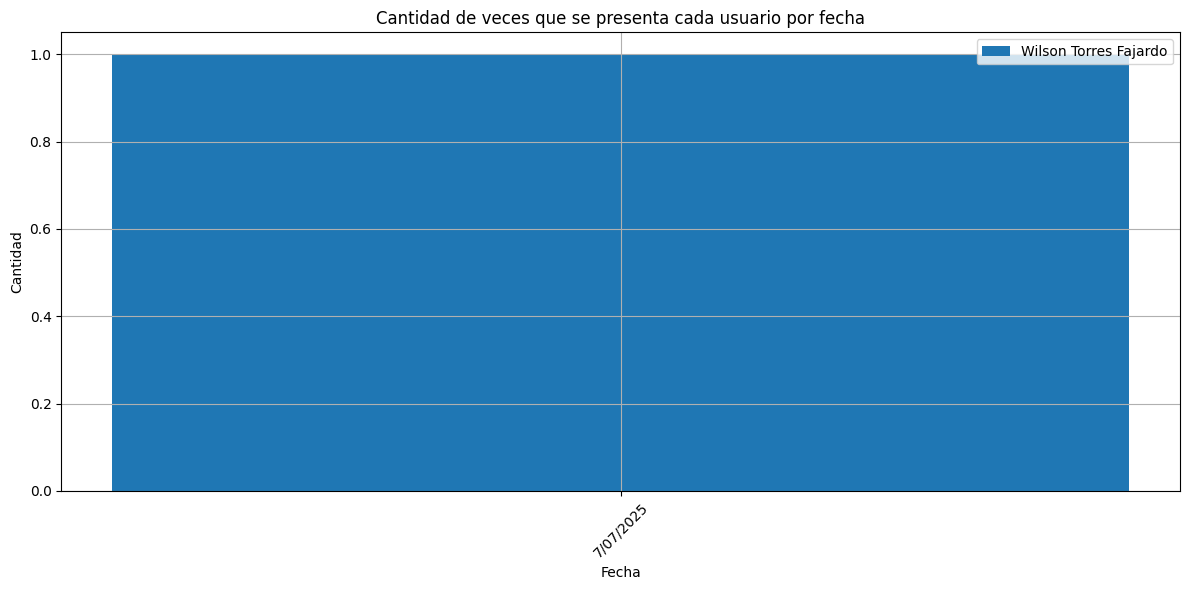

In [ ]:
# Agrupar los datos por NombreUsuario y Fecha y contar las ocurrencias
conteo_por_fecha = resultado.groupby(['NombreUsuario', 'Fecha']).size().reset_index(name='Conteo')

# Crear la gráfica de barras
plt.figure(figsize=(12, 6))
for nombre_usuario in conteo_por_fecha['NombreUsuario'].unique():
    datos_usuario = conteo_por_fecha[conteo_por_fecha['NombreUsuario'] == nombre_usuario]
    plt.bar(datos_usuario['Fecha'], datos_usuario['Conteo'], label=nombre_usuario)

# Personalizar la gráfica
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.title('Cantidad de veces que se presenta cada usuario por fecha')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

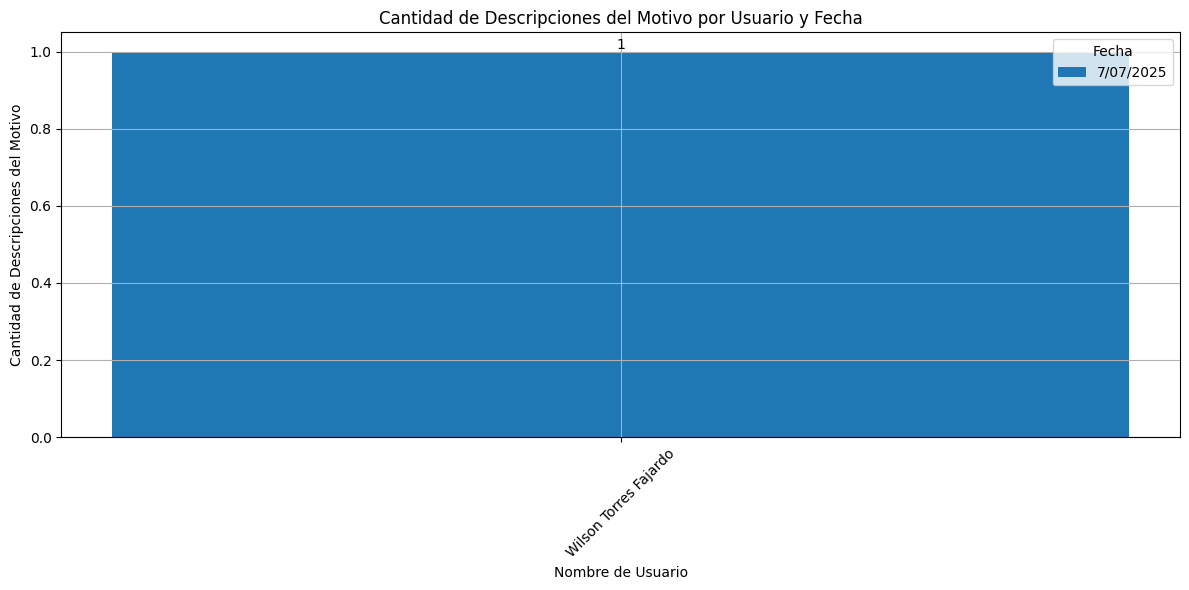

In [ ]:
# Agrupar los datos por NombreUsuario y Fecha y contar las descripciones del motivo
conteo_por_usuario_fecha = resultado.groupby(['NombreUsuario', 'Fecha'])['DescripcionMotivo'].count().reset_index(name='Cantidad')

# Crear la gráfica de barras
plt.figure(figsize=(12, 6))
for fecha in conteo_por_usuario_fecha['Fecha'].unique():
    datos_fecha = conteo_por_usuario_fecha[conteo_por_usuario_fecha['Fecha'] == fecha]
    plt.bar(datos_fecha['NombreUsuario'], datos_fecha['Cantidad'], label=fecha)

# Agregar etiquetas a las barras
for index, row in conteo_por_usuario_fecha.iterrows():
    plt.text(row['NombreUsuario'], row['Cantidad'], str(row['Cantidad']), ha='center', va='bottom')

# Personalizar la gráfica
plt.xlabel('Nombre de Usuario')
plt.ylabel('Cantidad de Descripciones del Motivo')
plt.title('Cantidad de Descripciones del Motivo por Usuario y Fecha')
plt.xticks(rotation=45)
plt.legend(title='Fecha')
plt.grid(True)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

2. Accion igual a 5 - Eliminar coche y Motivo 5

In [ ]:
# Filtrar las filas donde 'Accion' sea igual a 5
acciones_rev2 = acciones_rev[acciones_rev['Accion'].isin([5])]

acciones_rev2

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
94,7/07/2025,3:34:55,1210,2,NaN,0,5,Eliminar Coche,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<EliminarCoche Servicio=""CEIL30004"" Motivo=""14...",14,No se presenta operador a realizar servicio
95,7/07/2025,3:40:19,1137,1,NaN,0,5,Eliminar Coche,pcantor1,Paula Katherine Cantor Salamanca,GMZ04,"<EliminarCoche Servicio=""CEIKX0001"" Motivo=""14...",14,No se presenta operador a realizar servicio
100,7/07/2025,4:09:53,1137,6,NaN,0,5,Eliminar Coche,dyrojas1,Deisi Yanira Rojas Torres,GMZ04,"<EliminarCoche Servicio=""CEIKX0006"" Motivo=""14...",14,No se presenta operador a realizar servicio
101,7/07/2025,4:10:37,1182,9,NaN,0,5,Eliminar Coche,dyrojas1,Deisi Yanira Rojas Torres,GMZ04,"<EliminarCoche Servicio=""CEIJW0018"" Motivo=""14...",14,No se presenta operador a realizar servicio
105,7/07/2025,4:24:59,1062,8,NaN,0,5,Eliminar Coche,dyrojas1,Deisi Yanira Rojas Torres,GMZ04,"<EliminarCoche Servicio=""CEIKT0008"" Motivo=""14...",14,No se presenta operador a realizar servicio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,7/07/2025,11:23:42,1083,19,NaN,0,5,Eliminar Coche,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<EliminarCoche Servicio=""CEIKU0019"" Motivo=""14...",14,No se presenta operador a realizar servicio
670,7/07/2025,11:25:16,1103,19,Z50-2072,502072,5,Eliminar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<EliminarCoche Servicio=""CEIKZ0019"" Motivo=""2""...",2,Bus varado en la vía
690,7/07/2025,11:36:03,1091,30,Z50-4344,504344,5,Eliminar Coche,GWM,William Munar Gonzalez,GMZ02,"<EliminarCoche Servicio=""CEIKV0030"" Motivo=""19...",19,Fallas del SIRCI
732,7/07/2025,11:55:23,1201,1,Z50-4027,504027,5,Eliminar Coche,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<EliminarCoche Servicio=""CEIDO0001"" Motivo=""1""...",1,Concesionario no envía móvil


In [ ]:
# Lista de valores de Accion a incluir en el filtro - Motivo 5
valores_interes = [5]

# Filtrar el DataFrame por los valores de Accion de interés
acciones_rev2 = acciones_rev2[acciones_rev2['Motivo'].isin(valores_interes)]

acciones_rev2.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo


In [ ]:
# Llevar ruta_sae a eliminaciones Motivo 31

def calcular_lin(linea):
    
    filtro = (
        (rutas['linea'] == linea) 
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not rutas.loc[filtro].empty:
        # Obtener el primer valor
        tipo = rutas.loc[filtro, 'ruta_sae'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
acciones_rev2['ruta_sae'] = acciones_rev2.apply(
    lambda row: calcular_lin(
        row['Linea']
    ),
    axis=1
)
acciones_rev2

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae


In [ ]:
# Rellenar los valores vacíos (NaN) en la columna 'ruta_sae' con 1
acciones_rev2['ruta_sae'] = acciones_rev2['ruta_sae'].fillna(1)

acciones_rev2['ruta_sae'] = acciones_rev2['ruta_sae'].astype(int)

# Eliminar las filas donde 'ruta_sae' sea igual a 1
acciones_rev2 = acciones_rev2[acciones_rev2['ruta_sae'] != 1]

# Verificar los cambios
acciones_rev2.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae


In [ ]:
#concatenar los dataframe
acciones = acciones_rev2.copy()

acciones.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae


In [ ]:
# Ordenar el DataFrame por las columnas Fecha, Instante, Linea y Coche
acciones = acciones.sort_values(by=['Fecha', 'Instante', 'Linea', 'Coche'], ascending=True)

acciones.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae


In [ ]:
# Filtrar filas donde los valores de la columna 'NumBus' comiencen con 'Z50'
acciones = acciones[acciones['CodigoBus'].astype(str).str.startswith('Z50', 'Z52')]

# Reiniciar el índice después del filtrado
acciones.reset_index(drop=True, inplace=True)

acciones.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae


In [ ]:
# Convertir la columna 'Fecha' a formato datetime
acciones['Fecha'] = pd.to_datetime(acciones['Fecha'], errors='coerce')

acciones.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae


In [ ]:
# Definir una función para contar los caracteres en la cadena
def contar_caracteres(cadena):
    return len(cadena)

# Aplicar la función a la columna "Parametros" solo cuando la columna "Accion" es igual a 5
acciones['Conteo_Caracteres'] = acciones.loc[acciones['Accion'] == 5, 'Parametros'].apply(contar_caracteres)

# 1. Extraer cadena de servicio
def extraer_servicio_accion5(cadena, accion):
    if accion != 5:
        return None
    
    # Patrón para buscar el servicio
    patron_servicio = r'Servicio="([^"]*)"'
    
    # Buscar el servicio en la cadena
    servicio_match = re.search(patron_servicio, cadena)
    
    # Extraer el servicio si se encuentra
    servicio = servicio_match.group(1) if servicio_match else None
    
    return servicio

# Aplicar la función a la columna "Parametros"
acciones['Servicio_eliminado'] = acciones.apply(lambda row: extraer_servicio_accion5(row['Parametros'], row['Accion']), axis=1)

acciones.head(5)

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Conteo_Caracteres,Servicio_eliminado


In [ ]:
#Verificar el motivo de eliminación del servicio
def determinar_valor(cadena):
    conteo = len(cadena)
    if conteo <= 125:
        return "EliminarCoche"
    elif 125 < conteo <= 320:
        return "Desde Ruta / PosicionParada/Retirada Cochera"
    elif 320 < conteo <= 355:
        return "Desde Ruta / Hasta Ruta"
    elif 355 < conteo <= 365:
        return "Desde Ruta / PosicionParada/Hasta Ruta"
    elif 365 < conteo <= 430:
        return "Desde Ruta / Incorporacion Cochera/Hasta Ruta"
    elif 430 < conteo <= 455:
        return "Desde Ruta / PosicionParada/Retirada Cochera/Hasta Ruta"
    elif 455 < conteo <= 505:
        return "Desde Ruta / Retirada Cochera/ Incorporacion Cochera/Hasta Ruta"
    else:
        return "Desde Ruta / Posicion Parada / Retirada Cochera / Incorporacion Cochera/Hasta Ruta"

# Aplicar la función a la columna "Parametros" solo cuando la columna "Accion" es igual a 5
acciones['Forma_eliminada'] = acciones.loc[acciones['Accion'] == 5, 'Parametros'].apply(determinar_valor)

acciones.head(5)

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Conteo_Caracteres,Servicio_eliminado,Forma_eliminada


In [ ]:
# Obtener el conteo de cada valor único en la columna 'Servicio_eliminado'
conteo_valores = acciones['Servicio_eliminado'].value_counts()

# Mapear los valores de la columna 'Servicio_eliminado' al conteo correspondiente
acciones['Conteo_Servicio_eliminado'] = acciones['Servicio_eliminado'].map(conteo_valores)

# Mostrar el DataFrame con la nueva columna 'Conteo_Servicio_eliminado'
acciones.head(5)

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Conteo_Caracteres,Servicio_eliminado,Forma_eliminada,Conteo_Servicio_eliminado


In [ ]:
# Llevar ruta_sae a eliminaciones Motivo 31

def calcular_lin(svb):
    
    filtro = (
        (iph['ServBus'] == svb) 
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not iph.loc[filtro].empty:
        # Obtener el primer valor
        tipo = iph.loc[filtro, 'Viaje'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
acciones['Viaje'] = acciones.apply(
    lambda row: calcular_lin(
        row['Servicio_eliminado']
    ),
    axis=1
)

acciones

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Conteo_Caracteres,Servicio_eliminado,Forma_eliminada,Conteo_Servicio_eliminado,Viaje


Acciones de regulacion - Accion 36 (Cambiar de coche)

In [ ]:
acciones_rev3 = acciones_rev3.loc[acciones_rev3['Accion'] == 36]

acciones_rev3

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
225,7/07/2025,6:33:00,1103,1,Z50-4478,504478,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""31""><VehAnterior Servicio=...",31,Viaje Finalizado
271,7/07/2025,6:55:45,1385,4,Z50-2049,502049,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje
308,7/07/2025,7:23:25,1385,6,Z50-2052,502052,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje
339,7/07/2025,7:35:20,1210,4,Z50-4500,504500,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje
403,7/07/2025,8:22:39,1137,1,Z50-7086,507086,36,Cambiar Coche,PAE,Edith Patarroyo,GMZ04,"<CambiarBus Motivo=""12""><VehAnterior Servicio=...",12,Solicitud del área de programación
493,7/07/2025,8:51:31,1210,10,Z50-4505,504505,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje
495,7/07/2025,8:52:20,1208,2,Z50-2083,502083,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje
521,7/07/2025,9:19:55,1182,20,Z50-4179,504179,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje
528,7/07/2025,9:27:08,1182,21,Z50-4403,504403,36,Cambiar Coche,MAPB,Maicol Alexander Pita Blanco,GMZ04,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje
540,7/07/2025,9:37:33,1182,25,Z50-4430,504430,36,Cambiar Coche,MAPB,Maicol Alexander Pita Blanco,GMZ04,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje


In [ ]:
# Llevar ruta_sae a eliminaciones Motivo 31

def calcular_lin(svb):
    
    filtro = (
        (rutas['linea'] == svb) 
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not rutas.loc[filtro].empty:
        # Obtener el primer valor
        tipo = rutas.loc[filtro, 'ruta_sae'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
acciones_rev3['ruta_sae'] = acciones_rev3.apply(
    lambda row: calcular_lin(
        row['Linea']
    ),
    axis=1
)

acciones_rev3

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16588\3768654491.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acciones_rev3['ruta_sae'] = acciones_rev3.apply(


,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae
225,7/07/2025,6:33:00,1103,1,Z50-4478,504478,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""31""><VehAnterior Servicio=...",31,Viaje Finalizado,7946
271,7/07/2025,6:55:45,1385,4,Z50-2049,502049,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695
308,7/07/2025,7:23:25,1385,6,Z50-2052,502052,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695
339,7/07/2025,7:35:20,1210,4,Z50-4500,504500,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,6873
403,7/07/2025,8:22:39,1137,1,Z50-7086,507086,36,Cambiar Coche,PAE,Edith Patarroyo,GMZ04,"<CambiarBus Motivo=""12""><VehAnterior Servicio=...",12,Solicitud del área de programación,5024
493,7/07/2025,8:51:31,1210,10,Z50-4505,504505,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,6873
495,7/07/2025,8:52:20,1208,2,Z50-2083,502083,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,8452
521,7/07/2025,9:19:55,1182,20,Z50-4179,504179,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,8411
528,7/07/2025,9:27:08,1182,21,Z50-4403,504403,36,Cambiar Coche,MAPB,Maicol Alexander Pita Blanco,GMZ04,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,8411
540,7/07/2025,9:37:33,1182,25,Z50-4430,504430,36,Cambiar Coche,MAPB,Maicol Alexander Pita Blanco,GMZ04,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,8411


In [ ]:
# Rellenar los valores vacíos (NaN) en la columna 'ruta_sae' con 1
acciones_rev3['ruta_sae'] = acciones_rev3['ruta_sae'].fillna(1)

acciones_rev3['ruta_sae'] = acciones_rev3['ruta_sae'].astype(int)

# Eliminar las filas donde 'ruta_sae' sea igual a 1
acciones_rev3 = acciones_rev3[acciones_rev3['ruta_sae'] != 1]

# Verificar los cambios
acciones_rev3.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16588\884166993.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acciones_rev3['ruta_sae'] = acciones_rev3['ruta_sae'].fillna(1)
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16588\884166993.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acciones_rev3['ruta_sae'] = acciones_rev3['ruta_sae'].astype(int)


,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae
225,7/07/2025,6:33:00,1103,1,Z50-4478,504478,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""31""><VehAnterior Servicio=...",31,Viaje Finalizado,7946
271,7/07/2025,6:55:45,1385,4,Z50-2049,502049,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695
308,7/07/2025,7:23:25,1385,6,Z50-2052,502052,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695
339,7/07/2025,7:35:20,1210,4,Z50-4500,504500,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,6873
403,7/07/2025,8:22:39,1137,1,Z50-7086,507086,36,Cambiar Coche,PAE,Edith Patarroyo,GMZ04,"<CambiarBus Motivo=""12""><VehAnterior Servicio=...",12,Solicitud del área de programación,5024


In [ ]:
#Buscar el servicio de referencia

subcadena_buscar = "VehAnterior Servicio="

# desde la posición donde se encuentra "VehAnterior Servicio="
acciones_rev3['Servicio de Referencia'] = acciones_rev3['Parametros'].str.extract(f'{subcadena_buscar}(.{{10}})')[0]

# Ahora, df['Nueva Columna'] contiene la subcadena de 9 caracteres después de "VehAnterior Servicio="

# columna de tipo cadena (string)
acciones_rev3['Servicio de Referencia'] = acciones_rev3['Servicio de Referencia'].astype(str)

# Eliminar las comillas de la columna
acciones_rev3['Servicio de Referencia'] = acciones_rev3['Servicio de Referencia'].str.replace('"', '')

acciones_rev3.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Servicio de Referencia
225,7/07/2025,6:33:00,1103,1,Z50-4478,504478,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""31""><VehAnterior Servicio=...",31,Viaje Finalizado,7946,CEIKZ0001
271,7/07/2025,6:55:45,1385,4,Z50-2049,502049,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695,CEIHZ0004
308,7/07/2025,7:23:25,1385,6,Z50-2052,502052,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695,CEIHZ0006
339,7/07/2025,7:35:20,1210,4,Z50-4500,504500,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,6873,CEIL30009
403,7/07/2025,8:22:39,1137,1,Z50-7086,507086,36,Cambiar Coche,PAE,Edith Patarroyo,GMZ04,"<CambiarBus Motivo=""12""><VehAnterior Servicio=...",12,Solicitud del área de programación,5024,CEIKX0001


In [ ]:
# Encontrar la posición de "Viaje=" en la columna 'Parámetros'
acciones_rev3['Posicion'] = acciones_rev3['Parametros'].str.find("Viaje=")

# Extraer los últimos 2 caracteres de la subcadena a partir de la posición encontrada
acciones_rev3['Viaje Ini'] = acciones_rev3.apply(lambda row: row['Parametros'][row['Posicion']+6:row['Posicion']+9], axis=1)

# Reemplazar las comillas simples (') por un valor en blanco
acciones_rev3['Viaje Ini'] = acciones_rev3['Viaje Ini'].str.replace('"', '')

# Eliminar espacios en blanco al principio o al final de la cadena
acciones_rev3['Viaje Ini'] = acciones_rev3['Viaje Ini'].str.strip()

acciones_rev3.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Servicio de Referencia,Posicion,Viaje Ini
225,7/07/2025,6:33:00,1103,1,Z50-4478,504478,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""31""><VehAnterior Servicio=...",31,Viaje Finalizado,7946,CEIKZ0001,252,11
271,7/07/2025,6:55:45,1385,4,Z50-2049,502049,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695,CEIHZ0004,251,4
308,7/07/2025,7:23:25,1385,6,Z50-2052,502052,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695,CEIHZ0006,251,3
339,7/07/2025,7:35:20,1210,4,Z50-4500,504500,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,6873,CEIL30009,251,3
403,7/07/2025,8:22:39,1137,1,Z50-7086,507086,36,Cambiar Coche,PAE,Edith Patarroyo,GMZ04,"<CambiarBus Motivo=""12""><VehAnterior Servicio=...",12,Solicitud del área de programación,5024,CEIKX0001,251,4


In [ ]:
# Función para extraer 2 caracteres después de la segunda aparición de "Viaje="
def extract_viaje(row):
    matches = re.finditer(r'Viaje=', row['Parametros'])
    # Encontrar la segunda coincidencia
    match = next(matches, None)
    if match:
        match = next(matches, None)  # Segunda coincidencia
        if match:
            start = match.end()  # Posición de inicio después de la segunda coincidencia
            return row['Parametros'][start:start+4]  # Extraer 4 caracteres
    return None

# Aplicar la función a la columna Parametros y crear una nueva columna 'Viaje_extraido'
acciones_rev3['Viaje_fin'] = acciones_rev3.apply(extract_viaje, axis=1)

# Reemplazar las comillas simples (') por un valor en blanco
acciones_rev3['Viaje_fin'] = acciones_rev3['Viaje_fin'].str.replace('"', '')

# Eliminar espacios en blanco al principio o al final de la cadena
acciones_rev3['Viaje_fin'] = acciones_rev3['Viaje_fin'].str.strip()

acciones_rev3.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Servicio de Referencia,Posicion,Viaje Ini,Viaje_fin
225,7/07/2025,6:33:00,1103,1,Z50-4478,504478,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""31""><VehAnterior Servicio=...",31,Viaje Finalizado,7946,CEIKZ0001,252,11,8
271,7/07/2025,6:55:45,1385,4,Z50-2049,502049,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695,CEIHZ0004,251,4,7
308,7/07/2025,7:23:25,1385,6,Z50-2052,502052,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695,CEIHZ0006,251,3,6
339,7/07/2025,7:35:20,1210,4,Z50-4500,504500,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,6873,CEIL30009,251,3,6
403,7/07/2025,8:22:39,1137,1,Z50-7086,507086,36,Cambiar Coche,PAE,Edith Patarroyo,GMZ04,"<CambiarBus Motivo=""12""><VehAnterior Servicio=...",12,Solicitud del área de programación,5024,CEIKX0001,251,4,7


In [ ]:
#Buscar el servicio de referencia

subcadena_buscar = "VehNuevo Servicio="

# desde la posición donde se encuentra "VehAnterior Servicio="
acciones_rev3['Nombre Servicio'] = acciones_rev3['Parametros'].str.extract(f'{subcadena_buscar}(.{{10}})')[0]

# Ahora, df['Nueva Columna'] contiene la subcadena de 9 caracteres después de "VehAnterior Servicio="

# columna de tipo cadena (string)
acciones_rev3['Nombre Servicio'] = acciones_rev3['Nombre Servicio'].astype(str)

# Eliminar las comillas de la columna
acciones_rev3['Nombre Servicio'] = acciones_rev3['Nombre Servicio'].str.replace('"', '')

# Eliminar espacios en blanco al principio o al final de la cadena
acciones_rev3['Nombre Servicio'] = acciones_rev3['Nombre Servicio'].str.strip()

acciones_rev3.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Servicio de Referencia,Posicion,Viaje Ini,Viaje_fin,Nombre Servicio
225,7/07/2025,6:33:00,1103,1,Z50-4478,504478,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""31""><VehAnterior Servicio=...",31,Viaje Finalizado,7946,CEIKZ0001,252,11,8,CEIKZG001
271,7/07/2025,6:55:45,1385,4,Z50-2049,502049,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695,CEIHZ0004,251,4,7,CEIHZG004
308,7/07/2025,7:23:25,1385,6,Z50-2052,502052,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,7695,CEIHZ0006,251,3,6,CEIHZG006
339,7/07/2025,7:35:20,1210,4,Z50-4500,504500,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,GMZ05,"<CambiarBus Motivo=""26""><VehAnterior Servicio=...",26,Retoma de viaje,6873,CEIL30009,251,3,6,CEIL3G009
403,7/07/2025,8:22:39,1137,1,Z50-7086,507086,36,Cambiar Coche,PAE,Edith Patarroyo,GMZ04,"<CambiarBus Motivo=""12""><VehAnterior Servicio=...",12,Solicitud del área de programación,5024,CEIKX0001,251,4,7,CEIKXG001


In [ ]:
# Susituyente de sustituyente

acciones_rev3['Sustituyente de Sustituyente'] = acciones_rev3.apply(lambda row: 'Si' if row['Nombre Servicio'] == row['Servicio de Referencia'] else 'No', axis=1)

# Creando servicio original

acciones_rev3['Servicio Planificado'] = acciones_rev3['Nombre Servicio'].str[:5] + '0' + acciones_rev3['Nombre Servicio'].str[-3:]

# Crear una nueva columna 'Conteo' 

acciones_rev3['Numero de sustituyente'] = acciones_rev3.apply(lambda row: 
    len(acciones_rev3[(acciones_rev3['Servicio de Referencia'] < row['Servicio de Referencia']) & 
                    (acciones_rev3['Servicio Planificado'] == row['Servicio Planificado'])]) + 1, axis=1)

acciones_rev3.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,...,DescripcionMotivo,ruta_sae,Servicio de Referencia,Posicion,Viaje Ini,Viaje_fin,Nombre Servicio,Sustituyente de Sustituyente,Servicio Planificado,Numero de sustituyente
225,7/07/2025,6:33:00,1103,1,Z50-4478,504478,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,...,Viaje Finalizado,7946,CEIKZ0001,252,11,8,CEIKZG001,No,CEIKZ0001,1
271,7/07/2025,6:55:45,1385,4,Z50-2049,502049,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,...,Retoma de viaje,7695,CEIHZ0004,251,4,7,CEIHZG004,No,CEIHZ0004,1
308,7/07/2025,7:23:25,1385,6,Z50-2052,502052,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,...,Retoma de viaje,7695,CEIHZ0006,251,3,6,CEIHZG006,No,CEIHZ0006,1
339,7/07/2025,7:35:20,1210,4,Z50-4500,504500,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,...,Retoma de viaje,6873,CEIL30009,251,3,6,CEIL3G009,No,CEIL30009,1
403,7/07/2025,8:22:39,1137,1,Z50-7086,507086,36,Cambiar Coche,PAE,Edith Patarroyo,...,Solicitud del área de programación,5024,CEIKX0001,251,4,7,CEIKXG001,No,CEIKX0001,1


In [ ]:
#N Viajes

# Convierte las columnas 'Viaje Fin' y 'Viaje Ini' a tipo numérico (int)
acciones_rev3['Viaje_fin'] = acciones_rev3['Viaje_fin'].astype(int)
acciones_rev3['Viaje Ini'] = acciones_rev3['Viaje Ini'].astype(int)


def calcular_resultado(row):
    if row['Sustituyente de Sustituyente'] == "No" and \
        row['Numero de sustituyente'] >= 1 and \
        row['Viaje_fin'] > row['Viaje Ini']:
        return row['Viaje_fin'] - row['Viaje Ini']
    
    if row['Sustituyente de Sustituyente'] == "Si":
        viaje_ini_lookup = acciones_rev3[(acciones_rev3['Servicio de Referencia'] == row['Servicio de Referencia']) & (acciones_rev3['Nombre Servicio'] == row['Nombre Servicio'])]['Viaje Ini'].values
        if len(viaje_ini_lookup) == 0:
            return 1 if row['Viaje_fin'] == row['Viaje Ini'] else row['Viaje_fin'] - row['Viaje Ini']
        
        if row['Numero de sustituyente'] == 1:
            return row['Viaje_fin'] - row['Viaje Ini'] + 1
        
        viaje_ini_anterior = acciones_rev3[(acciones_rev3['Servicio Planificado'] == row['Servicio Planificado']) & (acciones_rev3['Numero de sustiituyente'] == row['Numero de sustituyente'] - 1)]['Viaje Ini'].values
        if len(viaje_ini_anterior) > 0:
            return viaje_ini_lookup[0] - row['Viaje Ini'] - 1
        
    if row['Sustituyente de Sustituyente'] == "No" and row['Viaje_fin'] == row['Viaje Ini']:
        return 1
    
    return None

acciones_rev3['N Viajes'] = acciones_rev3.apply(calcular_resultado, axis=1)

acciones_rev3

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,...,ruta_sae,Servicio de Referencia,Posicion,Viaje Ini,Viaje_fin,Nombre Servicio,Sustituyente de Sustituyente,Servicio Planificado,Numero de sustituyente,N Viajes
225,7/07/2025,6:33:00,1103,1,Z50-4478,504478,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,...,7946,CEIKZ0001,252,11,8,CEIKZG001,No,CEIKZ0001,1,NaN
271,7/07/2025,6:55:45,1385,4,Z50-2049,502049,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,...,7695,CEIHZ0004,251,4,7,CEIHZG004,No,CEIHZ0004,1,3.0
308,7/07/2025,7:23:25,1385,6,Z50-2052,502052,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,...,7695,CEIHZ0006,251,3,6,CEIHZG006,No,CEIHZ0006,1,3.0
339,7/07/2025,7:35:20,1210,4,Z50-4500,504500,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,...,6873,CEIL30009,251,3,6,CEIL3G009,No,CEIL30009,1,3.0
403,7/07/2025,8:22:39,1137,1,Z50-7086,507086,36,Cambiar Coche,PAE,Edith Patarroyo,...,5024,CEIKX0001,251,4,7,CEIKXG001,No,CEIKX0001,1,3.0
493,7/07/2025,8:51:31,1210,10,Z50-4505,504505,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,...,6873,CEIL30017,251,3,6,CEIL3G017,No,CEIL30017,1,3.0
495,7/07/2025,8:52:20,1208,2,Z50-2083,502083,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,...,8452,CEIL00002,251,4,7,CEIL0G002,No,CEIL00002,1,3.0
521,7/07/2025,9:19:55,1182,20,Z50-4179,504179,36,Cambiar Coche,CRSC,Sonia Constanza Correa Rodriguez,...,8411,CEIJW0011,251,5,9,CEIJWG011,No,CEIJW0011,1,4.0
528,7/07/2025,9:27:08,1182,21,Z50-4403,504403,36,Cambiar Coche,MAPB,Maicol Alexander Pita Blanco,...,8411,CEIJW0013,251,5,11,CEIJWG013,No,CEIJW0013,1,6.0
540,7/07/2025,9:37:33,1182,25,Z50-4430,504430,36,Cambiar Coche,MAPB,Maicol Alexander Pita Blanco,...,8411,CEIJW0021,251,5,8,CEIJWG021,No,CEIJW0021,1,3.0


Acción de regulación introducir coche

In [ ]:
acciones_rev4 = acciones_rev.copy()

acciones_rev4 = acciones_rev4.loc[acciones_rev4['Accion'] == 4]

acciones_rev4

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo
134,7/07/2025,5:24:10,1215,24,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151501"" ServicioCondu...",31,Viaje Finalizado
141,7/07/2025,5:26:47,1215,25,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151301"" ServicioCondu...",31,Viaje Finalizado
245,7/07/2025,6:45:14,1215,26,NaN,0,4,Introducir Coche,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<CrearCoche Servicio=""RTC151303"" ServicioCondu...",31,Viaje Finalizado
575,7/07/2025,10:03:05,1215,27,NaN,0,4,Introducir Coche,PAE,Edith Patarroyo,GMZ03,"<CrearCoche Servicio=""RTC151505"" ServicioCondu...",31,Viaje Finalizado
589,7/07/2025,10:14:07,1674,19,NaN,0,4,Introducir Coche,JIAG,Jinneth Alexandra Guzman,GMZ08,"<CrearCoche Servicio=""RTG741802"" ServicioCondu...",31,Viaje Finalizado


In [ ]:
# Llevar ruta_sae a eliminaciones Motivo 31

def calcular_lin(svb):
    
    filtro = (
        (rutas['linea'] == svb) 
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not rutas.loc[filtro].empty:
        # Obtener el primer valor
        tipo = rutas.loc[filtro, 'ruta_sae'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
acciones_rev4['ruta_sae'] = acciones_rev4.apply(
    lambda row: calcular_lin(
        row['Linea']
    ),
    axis=1
)

acciones_rev4

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae
134,7/07/2025,5:24:10,1215,24,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151501"" ServicioCondu...",31,Viaje Finalizado,8103
141,7/07/2025,5:26:47,1215,25,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151301"" ServicioCondu...",31,Viaje Finalizado,8103
245,7/07/2025,6:45:14,1215,26,NaN,0,4,Introducir Coche,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<CrearCoche Servicio=""RTC151303"" ServicioCondu...",31,Viaje Finalizado,8103
575,7/07/2025,10:03:05,1215,27,NaN,0,4,Introducir Coche,PAE,Edith Patarroyo,GMZ03,"<CrearCoche Servicio=""RTC151505"" ServicioCondu...",31,Viaje Finalizado,8103
589,7/07/2025,10:14:07,1674,19,NaN,0,4,Introducir Coche,JIAG,Jinneth Alexandra Guzman,GMZ08,"<CrearCoche Servicio=""RTG741802"" ServicioCondu...",31,Viaje Finalizado,8414


In [ ]:
# Rellenar los valores vacíos (NaN) en la columna 'ruta_sae' con 1
acciones_rev4['ruta_sae'] = acciones_rev4['ruta_sae'].fillna(1)

acciones_rev4['ruta_sae'] = acciones_rev4['ruta_sae'].astype(int)

# Eliminar las filas donde 'ruta_sae' sea igual a 1
acciones_rev4 = acciones_rev4[acciones_rev4['ruta_sae'] != 1]

# Verificar los cambios
acciones_rev4.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae
134,7/07/2025,5:24:10,1215,24,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151501"" ServicioCondu...",31,Viaje Finalizado,8103
141,7/07/2025,5:26:47,1215,25,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151301"" ServicioCondu...",31,Viaje Finalizado,8103
245,7/07/2025,6:45:14,1215,26,NaN,0,4,Introducir Coche,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<CrearCoche Servicio=""RTC151303"" ServicioCondu...",31,Viaje Finalizado,8103
575,7/07/2025,10:03:05,1215,27,NaN,0,4,Introducir Coche,PAE,Edith Patarroyo,GMZ03,"<CrearCoche Servicio=""RTC151505"" ServicioCondu...",31,Viaje Finalizado,8103
589,7/07/2025,10:14:07,1674,19,NaN,0,4,Introducir Coche,JIAG,Jinneth Alexandra Guzman,GMZ08,"<CrearCoche Servicio=""RTG741802"" ServicioCondu...",31,Viaje Finalizado,8414


In [ ]:
#Buscar el servicio de referencia

subcadena_buscar = "Referencia Servicio="

# desde la posición donde se encuentra "VehAnterior Servicio="
acciones_rev4['Servicio de Referencia'] = acciones_rev4['Parametros'].str.extract(f'{subcadena_buscar}(.{{10}})')[0]

# Ahora, df['Nueva Columna'] contiene la subcadena de 9 caracteres después de "VehAnterior Servicio="

# columna de tipo cadena (string)
acciones_rev4['Servicio de Referencia'] = acciones_rev4['Servicio de Referencia'].astype(str)

# Eliminar las comillas de la columna
acciones_rev4['Servicio de Referencia'] = acciones_rev4['Servicio de Referencia'].str.replace('"', '')

acciones_rev4.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Servicio de Referencia
134,7/07/2025,5:24:10,1215,24,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151501"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10014
141,7/07/2025,5:26:47,1215,25,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151301"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10012
245,7/07/2025,6:45:14,1215,26,NaN,0,4,Introducir Coche,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<CrearCoche Servicio=""RTC151303"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10012
575,7/07/2025,10:03:05,1215,27,NaN,0,4,Introducir Coche,PAE,Edith Patarroyo,GMZ03,"<CrearCoche Servicio=""RTC151505"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10014
589,7/07/2025,10:14:07,1674,19,NaN,0,4,Introducir Coche,JIAG,Jinneth Alexandra Guzman,GMZ08,"<CrearCoche Servicio=""RTG741802"" ServicioCondu...",31,Viaje Finalizado,8414,CEIKY0018


In [ ]:
# Encontrar la posición de "Viaje=" en la columna 'Parámetros'
acciones_rev4['Posicion'] = acciones_rev4['Parametros'].str.find("IdViaje=")

# Extraer los últimos 2 caracteres de la subcadena a partir de la posición encontrada
acciones_rev4['Viaje Ini'] = acciones_rev4.apply(lambda row: row['Parametros'][row['Posicion']+8:row['Posicion']+11], axis=1)

# Reemplazar las comillas simples (') por un valor en blanco
acciones_rev4['Viaje Ini'] = acciones_rev4['Viaje Ini'].str.replace('"', '')

# Eliminar espacios en blanco al principio o al final de la cadena
acciones_rev4['Viaje Ini'] = acciones_rev4['Viaje Ini'].str.strip()

acciones_rev4.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Servicio de Referencia,Posicion,Viaje Ini
134,7/07/2025,5:24:10,1215,24,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151501"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10014,247,2
141,7/07/2025,5:26:47,1215,25,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151301"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10012,247,2
245,7/07/2025,6:45:14,1215,26,NaN,0,4,Introducir Coche,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<CrearCoche Servicio=""RTC151303"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10012,383,3
575,7/07/2025,10:03:05,1215,27,NaN,0,4,Introducir Coche,PAE,Edith Patarroyo,GMZ03,"<CrearCoche Servicio=""RTC151505"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10014,383,4
589,7/07/2025,10:14:07,1674,19,NaN,0,4,Introducir Coche,JIAG,Jinneth Alexandra Guzman,GMZ08,"<CrearCoche Servicio=""RTG741802"" ServicioCondu...",31,Viaje Finalizado,8414,CEIKY0018,247,3


In [ ]:
# Función para extraer 2 caracteres después de la segunda aparición de "Viaje="
def extract_viaje(row):
    matches = re.finditer(r'IdViaje=', row['Parametros'])
    # Encontrar la segunda coincidencia
    match = next(matches, None)
    if match:
        match = next(matches, None)  # Segunda coincidencia
        if match:
            start = match.end()  # Posición de inicio después de la segunda coincidencia
            return row['Parametros'][start:start+4]  # Extraer 4 caracteres
    return None

# Aplicar la función a la columna Parametros y crear una nueva columna 'Viaje_extraido'
acciones_rev4['Viaje_fin'] = acciones_rev4.apply(extract_viaje, axis=1)

# Reemplazar las comillas simples (') por un valor en blanco
acciones_rev4['Viaje_fin'] = acciones_rev4['Viaje_fin'].str.replace('"', '')

# Eliminar espacios en blanco al principio o al final de la cadena
acciones_rev4['Viaje_fin'] = acciones_rev4['Viaje_fin'].str.strip()

acciones_rev4

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Servicio de Referencia,Posicion,Viaje Ini,Viaje_fin
134,7/07/2025,5:24:10,1215,24,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151501"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10014,247,2,3
141,7/07/2025,5:26:47,1215,25,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151301"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10012,247,2,2
245,7/07/2025,6:45:14,1215,26,NaN,0,4,Introducir Coche,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<CrearCoche Servicio=""RTC151303"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10012,383,3,3
575,7/07/2025,10:03:05,1215,27,NaN,0,4,Introducir Coche,PAE,Edith Patarroyo,GMZ03,"<CrearCoche Servicio=""RTC151505"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10014,383,4,5
589,7/07/2025,10:14:07,1674,19,NaN,0,4,Introducir Coche,JIAG,Jinneth Alexandra Guzman,GMZ08,"<CrearCoche Servicio=""RTG741802"" ServicioCondu...",31,Viaje Finalizado,8414,CEIKY0018,247,3,4


In [ ]:
#Buscar el servicio

subcadena_buscar = "Servicio="

# desde la posición donde se encuentra "VehAnterior Servicio="
acciones_rev4['Nombre Servicio'] = acciones_rev4['Parametros'].str.extract(f'{subcadena_buscar}(.{{10}})')[0]

# Ahora, df['Nueva Columna'] contiene la subcadena de 9 caracteres después de "VehAnterior Servicio="

# columna de tipo cadena (string)
acciones_rev4['Nombre Servicio'] = acciones_rev4['Nombre Servicio'].astype(str)

# Eliminar las comillas de la columna
acciones_rev4['Nombre Servicio'] = acciones_rev4['Nombre Servicio'].str.replace('"', '')

acciones_rev4

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,Puesto,Parametros,Motivo,DescripcionMotivo,ruta_sae,Servicio de Referencia,Posicion,Viaje Ini,Viaje_fin,Nombre Servicio
134,7/07/2025,5:24:10,1215,24,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151501"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10014,247,2,3,RTC151501
141,7/07/2025,5:26:47,1215,25,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,GMZ11,"<CrearCoche Servicio=""RTC151301"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10012,247,2,2,RTC151301
245,7/07/2025,6:45:14,1215,26,NaN,0,4,Introducir Coche,LMVG,Laura Marcela Vargas Gutierrez,GMZ03,"<CrearCoche Servicio=""RTC151303"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10012,383,3,3,RTC151303
575,7/07/2025,10:03:05,1215,27,NaN,0,4,Introducir Coche,PAE,Edith Patarroyo,GMZ03,"<CrearCoche Servicio=""RTC151505"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10014,383,4,5,RTC151505
589,7/07/2025,10:14:07,1674,19,NaN,0,4,Introducir Coche,JIAG,Jinneth Alexandra Guzman,GMZ08,"<CrearCoche Servicio=""RTG741802"" ServicioCondu...",31,Viaje Finalizado,8414,CEIKY0018,247,3,4,RTG741802


In [ ]:
#Buscar incorporación

# Función personalizada para extraer la subcadena
def extraer_incorporacion_cochera(parametros):
    start = parametros.find("Incorporacion Cochera=")
    if start != -1:
        substring = parametros[start + len("Incorporacion Cochera="):start + len("Incorporacion Cochera=") + 9]
        return substring
    else:
        return None

# Aplicar la función personalizada a la columna 'Parámetros'
acciones_rev4['Con Incorporacion'] = acciones_rev4['Parametros'].apply(lambda x: 1 if extraer_incorporacion_cochera(x) is not None else 0)

acciones_rev4

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,...,Parametros,Motivo,DescripcionMotivo,ruta_sae,Servicio de Referencia,Posicion,Viaje Ini,Viaje_fin,Nombre Servicio,Con Incorporacion
134,7/07/2025,5:24:10,1215,24,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,...,"<CrearCoche Servicio=""RTC151501"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10014,247,2,3,RTC151501,0
141,7/07/2025,5:26:47,1215,25,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,...,"<CrearCoche Servicio=""RTC151301"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10012,247,2,2,RTC151301,0
245,7/07/2025,6:45:14,1215,26,NaN,0,4,Introducir Coche,LMVG,Laura Marcela Vargas Gutierrez,...,"<CrearCoche Servicio=""RTC151303"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10012,383,3,3,RTC151303,1
575,7/07/2025,10:03:05,1215,27,NaN,0,4,Introducir Coche,PAE,Edith Patarroyo,...,"<CrearCoche Servicio=""RTC151505"" ServicioCondu...",31,Viaje Finalizado,8103,CEIL10014,383,4,5,RTC151505,1
589,7/07/2025,10:14:07,1674,19,NaN,0,4,Introducir Coche,JIAG,Jinneth Alexandra Guzman,...,"<CrearCoche Servicio=""RTG741802"" ServicioCondu...",31,Viaje Finalizado,8414,CEIKY0018,247,3,4,RTG741802,0


In [ ]:
#N Viajes

# Convierte las columnas 'Viaje Fin' y 'Viaje Ini' a tipo numérico (int)
acciones_rev4['Viaje_fin'] = acciones_rev4['Viaje_fin'].astype(int)
acciones_rev4['Viaje Ini'] = acciones_rev4['Viaje Ini'].astype(int)

# Primera condición: LOOKUPVALUE(Retomas[Viaje Ini]; Retomas[Servicio de Referencia]; Retomas[Nombre Servicio]) = 2
# y Retomas[Con Incorporación] = 1
condicion_1 = (acciones_rev4['Viaje Ini'] == 2) & (acciones_rev4['Con Incorporacion'] == 1)

# Si se cumple la primera condición, el resultado es 0; de lo contrario, calculamos Retomas[Viaje Fin] - Retomas[Viaje Ini] + 1
acciones_rev4['N Viajes'] = 0
acciones_rev4.loc[~condicion_1, 'N Viajes'] = acciones_rev4['Viaje_fin'] - acciones_rev4['Viaje Ini'] + 1

acciones_rev4

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,...,Motivo,DescripcionMotivo,ruta_sae,Servicio de Referencia,Posicion,Viaje Ini,Viaje_fin,Nombre Servicio,Con Incorporacion,N Viajes
134,7/07/2025,5:24:10,1215,24,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,...,31,Viaje Finalizado,8103,CEIL10014,247,2,3,RTC151501,0,2
141,7/07/2025,5:26:47,1215,25,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,...,31,Viaje Finalizado,8103,CEIL10012,247,2,2,RTC151301,0,1
245,7/07/2025,6:45:14,1215,26,NaN,0,4,Introducir Coche,LMVG,Laura Marcela Vargas Gutierrez,...,31,Viaje Finalizado,8103,CEIL10012,383,3,3,RTC151303,1,1
575,7/07/2025,10:03:05,1215,27,NaN,0,4,Introducir Coche,PAE,Edith Patarroyo,...,31,Viaje Finalizado,8103,CEIL10014,383,4,5,RTC151505,1,2
589,7/07/2025,10:14:07,1674,19,NaN,0,4,Introducir Coche,JIAG,Jinneth Alexandra Guzman,...,31,Viaje Finalizado,8414,CEIKY0018,247,3,4,RTG741802,0,2


In [ ]:
# Función para Servicio Planificado

def buscar_valor(row):
    if row['Servicio de Referencia'][:2] == "RT":
        return acciones_rev4[acciones_rev4['Nombre Servicio'] == row['Servicio de Referencia']]['Servicio de Referencia'].values[0]
    else:
        return row['Servicio de Referencia']

# Aplicar la función personalizada a las filas del DataFrame
acciones_rev4['Servicio Planificado'] = acciones_rev4.apply(buscar_valor, axis=1)

acciones_rev4.head()

,Fecha,Instante,Linea,Coche,CodigoBus,NumBus,Accion,DescripcionAccion,Usuario,NombreUsuario,...,DescripcionMotivo,ruta_sae,Servicio de Referencia,Posicion,Viaje Ini,Viaje_fin,Nombre Servicio,Con Incorporacion,N Viajes,Servicio Planificado
134,7/07/2025,5:24:10,1215,24,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,...,Viaje Finalizado,8103,CEIL10014,247,2,3,RTC151501,0,2,CEIL10014
141,7/07/2025,5:26:47,1215,25,NaN,0,4,Introducir Coche,BRGU,Bryan Guzman,...,Viaje Finalizado,8103,CEIL10012,247,2,2,RTC151301,0,1,CEIL10012
245,7/07/2025,6:45:14,1215,26,NaN,0,4,Introducir Coche,LMVG,Laura Marcela Vargas Gutierrez,...,Viaje Finalizado,8103,CEIL10012,383,3,3,RTC151303,1,1,CEIL10012
575,7/07/2025,10:03:05,1215,27,NaN,0,4,Introducir Coche,PAE,Edith Patarroyo,...,Viaje Finalizado,8103,CEIL10014,383,4,5,RTC151505,1,2,CEIL10014
589,7/07/2025,10:14:07,1674,19,NaN,0,4,Introducir Coche,JIAG,Jinneth Alexandra Guzman,...,Viaje Finalizado,8414,CEIKY0018,247,3,4,RTG741802,0,2,CEIKY0018


In [ ]:
# #exportar acciones de regulación
# acciones.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Notas/acciones_eliminación.csv', sep= ';', index=False)

In [ ]:
# #exportar notas
# notas.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Notas/notas_acciones_eliminación.csv', sep= ';', index=False)

In [ ]:
#exportar desglosado
desglosado.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Notas/{dia}_desglosado_eliminación.csv', sep= ';', index=False)